[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/notebooks/EN/chapter16_lecture_notebook.ipynb)

# Advanced Time Series Analysis and Forecasting — Chapter 16: Explosive roots and bubbles

*Lecture notebook (self-study chapter). Daniel Traian Pele, Bucharest University of Economic Studies.*

- Rational bubbles: Blanchard-Watson and Evans bubbles; why whole-sample tests miss them.
- Explosive autoregressions: Cauchy limits, mildly explosive roots, the Cauchy confidence interval.
- Recursive tests: SADF, GSADF, BSADF; critical values; size under changing volatility (wild bootstrap); pointwise and family-wise dating.
- Date-stamping accuracy, real-time monitoring with a CUSUM boundary, evaluation of early warnings (ROC, AUC, base rates).
- Fundamentals against prices (US and Romanian housing), LPPLS inference on Shanghai 2015, five historical episodes, and a GSADF screen of the course data.
- Monte Carlo and bootstrap sizes are smaller than on the slides, so that everything runs on one CPU core; the LPPLS indicator series are read from the cached files of the chapter.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_16'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/ATS - Modelarea avansata a seriilor de timp/repo/notebooks/EN


In [2]:
# the residual unit-root test of the LPPLS filter uses arch (Phillips-Perron)
%pip install -q arch

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## The engine

- Window regressions by cumulated cross-products: `psy` (ADF, SADF, GSADF, BSADF, optional lags), `bsadf_paths`, `psy_cv` (Monte Carlo), `wild_cv` (wild bootstrap), `episodes` (date-stamping).
- Simulations: `blanchard_watson`, `evans_price`, `bubble_collapse`, `ar1_explosive`.
- Monitoring: `csw_constant`, `cusum_monitor`. LPPLS: `lppl_fit`, `lppl_conditions`, `confidence_series`, `tc_profile`. Evaluation: `future_fall`, `auc`, `roc`, `block_bootstrap_auc`, `alarm_table`.

In [6]:
import io
# the cached indicator series: this folder, the chapter folder of a local copy, or GitHub (read_cached)
HERE = next((p for p in ('.', '../../Quantlets/Ch_16', '../Quantlets/Ch_16', 'Quantlets/Ch_16') if os.path.exists(os.path.join(p, 'ch16_ci_ssec.csv'))), '.')
PROCS = 1
SEED = 2026
END = '2026-09-18'
SAMPLES = {'sp500': ('GSPC.INDX', False, '1990-01-01', '2004-12-31', 'S&P 500, 1990-2004'), 'ndx': ('NDX.INDX', False, '1990-01-01', '2004-12-31', 'Nasdaq 100, 1990-2004'), 'ssec': ('SSEC.INDX', False, '2010-01-01', '2018-12-31', 'Shanghai Composite, 2010-2018'), 'btc': ('BTC-USD.CC', True, '2014-09-17', '2023-12-31', 'Bitcoin, 2014-2023'), 'bet': ('BET', False, '2000-01-01', '2012-12-31', 'BET, 2000-2012')}
PEAKS = {'sp500': [('1999-06-01', '2000-12-31')], 'ndx': [('1999-06-01', '2000-12-31')], 'ssec': [('2015-01-01', '2015-12-31')], 'btc': [('2017-06-01', '2018-03-31'), ('2021-01-01', '2021-06-30')], 'bet': [('2007-01-01', '2007-12-31')]}
COLORS = {'sp500': st.MainBlue, 'ndx': st.Teal, 'ssec': st.Orange, 'btc': st.Amber, 'bet': st.Crimson}
SHADE = '#DCE6F2'
CRASH, HORIZON = 0.2, 182
RO_END = '2026-03-31'
TAU = 52
_MEM = {}
CSV_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/Quantlets/Ch_16/'
EVAL = {'sp500': ('GSPC.INDX', False, '1990-01-01', '1993-01-01'), 'btc': ('BTC-USD.CC', True, '2011-01-01', '2014-01-01')}
EXCLUDE = ('.GBOND', 'VIX', 'USDT', 'USDC', 'DAI', 'EURRON.FOREX', 'BTBETRETF', 'IBIT', 'ETHA')
LPPLS_SEARCH = {'m': (0.0, 1.0), 'w': (1.0, 50.0), 'tc_frac': (0.0, 0.3333333333333333), 'damping_min': 1.0}
LPPLS_FILTER = {'m': (0.01, 0.99), 'w': (2.0, 25.0), 'tc_frac': (0.0, 0.2), 'osc_min': 2.5, 'rel_err_max': 0.15, 'lomb_alpha': 0.1, 'ar1_alpha': 0.1}
WINDOWS = [750, 725, 700, 675, 650, 625, 600, 575, 550, 525, 500, 475, 450, 425, 400, 375, 350, 325, 300, 275, 250, 225, 200, 175, 150, 125, 100, 75, 50]


def _cums(y):
    """Cumulative sums for the regression Delta y_t = a + delta y_{t-1} (rows t = 1..n); y is (n+1,) or (R, n+1)."""
    y = np.atleast_2d(np.asarray(y, float))
    x, z = y[:, :-1], np.diff(y, axis=1)
    pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1)), np.cumsum(a, axis=1)], axis=1)   # noqa: E731
    return pad(x), pad(x * x), pad(z), pad(z * z), pad(x * z)


def _adf_end(C, e, s):
    """t-statistic of delta on the windows [s, e] (s: vector of first rows, e: last row), for every replication."""
    Sx, Sxx, Sz, Szz, Sxz = (c[:, e + 1][:, None] - c[:, s] for c in C)
    n = (e + 1 - s).astype(float)
    den = n * Sxx - Sx ** 2
    b = (n * Sxz - Sx * Sz) / den
    a = (Sz - b * Sx) / n
    ssr = np.maximum(Szz - a * Sz - b * Sxz, 1e-300)
    return b / np.sqrt(ssr / (n - 2) * n / den)


def adf_window(y):
    """Right-tailed ADF on one window: intercept a, slope delta, its standard error and the t-statistic."""
    y = np.asarray(y, float)
    x, z = y[:-1], np.diff(y)
    X = np.column_stack([np.ones_like(x), x])
    beta, *_ = np.linalg.lstsq(X, z, rcond=None)
    e = z - X @ beta
    s2 = e @ e / (len(z) - 2)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[1, 1])
    return dict(a=float(beta[0]), delta=float(beta[1]), se=float(se), t=float(beta[1] / se), n=len(z))


def min_window(T, r0=None):
    """Smallest window of Phillips, Shi and Yu (2015): r0 = 0.01 + 1.8 / sqrt(T); w0 = floor(r0 T)."""
    r0 = 0.01 + 1.8 / np.sqrt(T) if r0 is None else r0
    return int(np.floor(r0 * T)), float(r0)


def _lag_design(y, k):
    """Rows t = k+1..n of the ADF regression with k lagged differences: z_t = Delta y_t,
    x_t = (1, y_{t-1}, Delta y_{t-1}, ..., Delta y_{t-k}); y is (R, n+1)."""
    dy = np.diff(y, axis=1)
    n = dy.shape[1]
    cols = [np.ones_like(dy[:, k:]), y[:, k:n]] + [dy[:, k - j:n - j] for j in range(1, k + 1)]
    return np.stack(cols, axis=2), dy[:, k:]


def _bsadf_lags(Y, w0, k, chunk=16):
    """BSADF and forward sequences with k lagged differences (cumulated cross-products, batched solves); entries
    before row k + w0 are NaN; the output has n columns like the k = 0 version."""
    R, n = Y.shape[0], Y.shape[1] - 1
    bs, fw = np.full((R, n), np.nan), np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        X, z = _lag_design(Y[i:i + chunk], k)
        m, p = X.shape[1], X.shape[2]
        pad = lambda a: np.concatenate([np.zeros((a.shape[0], 1) + a.shape[2:]), np.cumsum(a, axis=1)], axis=1)   # noqa: E731
        CXX = pad(np.einsum('rti,rtj->rtij', X, X))
        CXz = pad(X * z[:, :, None])
        Czz = pad(z * z)
        for e in range(w0 - 1, m):
            s_ = np.arange(0, e - w0 + 2)
            XX = CXX[:, e + 1][:, None] - CXX[:, s_]
            Xz = CXz[:, e + 1][:, None] - CXz[:, s_]
            zz = Czz[:, e + 1][:, None] - Czz[:, s_]
            inv = np.linalg.inv(XX)
            b = np.einsum('rsij,rsj->rsi', inv, Xz)
            ssr = np.maximum(zz - np.einsum('rsi,rsi->rs', b, Xz), 1e-300)
            nn = (e + 1 - s_)[None, :]
            t = b[..., 1] / np.sqrt(ssr / (nn - p) * inv[..., 1, 1])
            bs[i:i + chunk, e + k] = t.max(axis=1)
            fw[i:i + chunk, e + k] = t[:, 0]
    return bs, fw


def psy(y, r0=None, w0=None, k=0):
    """ADF (whole sample), SADF (sup of forward-expanding ADF), GSADF (sup over start and end points), the BSADF
    sequence (sup over start points for each end point) and the start point that attains it (k = 0); k > 0 adds k
    lagged differences to every window regression."""
    y = np.asarray(y, float)
    n = len(y) - 1
    if w0 is None:
        w0, r0 = min_window(n, r0)
    if k:
        bs, fw = _bsadf_lags(y[None, :], w0, k)
        return dict(adf=float(fw[0, -1]), sadf=float(np.nanmax(fw)), gsadf=float(np.nanmax(bs)), bsadf=bs[0], fwd=fw[0],
                    w0=int(w0), r0=r0, n=n, k=k)
    C = _cums(y)
    bsadf, fwd, arg = np.full(n, np.nan), np.full(n, np.nan), np.full(n, -1)
    for e in range(w0 - 1, n):
        stat = _adf_end(C, e, np.arange(0, e - w0 + 2))[0]
        bsadf[e], fwd[e], arg[e] = stat.max(), stat[0], int(np.argmax(stat))
    return dict(adf=float(fwd[-1]), sadf=float(np.nanmax(fwd)), gsadf=float(np.nanmax(bsadf)), bsadf=bsadf, fwd=fwd,
                start=arg, w0=int(w0), r0=r0, n=n, k=0)


def bsadf_paths(Y, w0, chunk=64, k=0):
    """BSADF and forward (SADF) sequences for several paths (rows of Y), vectorised over start points and paths."""
    Y = np.atleast_2d(np.asarray(Y, float))
    if k:
        return _bsadf_lags(Y, w0, k)
    R, n = Y.shape[0], Y.shape[1] - 1
    bs, fw = np.full((R, n), np.nan), np.full((R, n), np.nan)
    for i in range(0, R, chunk):
        C = _cums(Y[i:i + chunk])
        for e in range(w0 - 1, n):
            stat = _adf_end(C, e, np.arange(0, e - w0 + 2))
            bs[i:i + chunk, e] = stat.max(axis=1)
            fw[i:i + chunk, e] = stat[:, 0]
    return bs, fw


def bic_lag(y, kmax):
    """Lag order of the null model Delta y_t = mu + sum_j phi_j Delta y_{t-j} + e_t chosen by BIC (common sample)."""
    dy = np.diff(np.asarray(y, float))
    z = dy[kmax:]
    best = (np.inf, 0)
    for k in range(kmax + 1):
        X = np.column_stack([np.ones_like(z)] + [dy[kmax - j:len(dy) - j] for j in range(1, k + 1)])
        e = z - X @ np.linalg.lstsq(X, z, rcond=None)[0]
        bic = len(z) * np.log(e @ e / len(z)) + (k + 1) * np.log(len(z))
        best = min(best, (bic, k))
    return best[1]


def null_paths(T, R, rng, sig=None):
    """Random walk with a weak drift, y_t = T^(-1) + y_{t-1} + sig_t e_t (PSY 2015); sig: optional volatility path."""
    e = rng.standard_normal((R, T)) * (1.0 if sig is None else np.asarray(sig)[None, :])
    return np.concatenate([np.zeros((R, 1)), np.cumsum(1.0 / T + e, axis=1)], axis=1)


def psy_cv(T, w0, R=2000, seed=2026, probs=(0.90, 0.95, 0.99)):
    """Monte Carlo critical values under the null: quantiles of ADF, SADF and GSADF, the pointwise 95% quantile of
    BSADF at each end point, and the null draws."""
    rng = np.random.default_rng(seed)
    bs, fw = bsadf_paths(null_paths(T, R, rng), w0)
    q = lambda a: {f'{int(round(100 * p))}': float(np.quantile(a, p)) for p in probs}   # noqa: E731
    return dict(adf=q(fw[:, -1]), sadf=q(np.nanmax(fw, axis=1)), gsadf=q(np.nanmax(bs, axis=1)),
                bsadf95=np.nanquantile(bs, 0.95, axis=0), draws=dict(gsadf=np.nanmax(bs, axis=1), sadf=np.nanmax(fw, axis=1),
                                                                    adf=fw[:, -1]), bs=bs)


def wild_cv(y, w0, B=499, seed=2026, tau=None, k=0):
    """Wild bootstrap of Phillips and Shi (2020): residuals of the null model Delta y_t = mu + sum_j phi_j Delta y_{t-j}
    + e_t times Rademacher signs, Delta y*_t = sum_j phi_j Delta y*_{t-j} + w_t e_t, cumulated into paths with a unit
    root and the volatility pattern of the data. Returns the pointwise 95% BSADF sequence, the 95% quantile of the
    sample maximum (GSADF: family-wise over the whole sample) and, when tau is given, for every end point the 95%
    quantile of the maximum of BSADF over the last tau end points (family-wise over a moving window)."""
    rng = np.random.default_rng(seed)
    dy = np.diff(np.asarray(y, float))
    if k:
        X = np.column_stack([np.ones(len(dy) - k)] + [dy[k - j:len(dy) - j] for j in range(1, k + 1)])
        phi = np.linalg.lstsq(X, dy[k:], rcond=None)[0]
        e = dy[k:] - X @ phi
        W = rng.choice([-1.0, 1.0], size=(B, len(e)))
        D = np.zeros((B, len(dy)))
        D[:, :k] = dy[:k] - dy.mean()
        for t in range(k, len(dy)):
            D[:, t] = sum(phi[j] * D[:, t - j] for j in range(1, k + 1)) + W[:, t - k] * e[t - k]
    else:
        e = dy - dy.mean()
        D = rng.choice([-1.0, 1.0], size=(B, len(e))) * e
    Y = np.concatenate([np.zeros((B, 1)), np.cumsum(D, axis=1)], axis=1)
    bs, fw = bsadf_paths(Y, w0, k=k)
    out = dict(bsadf95=np.nanquantile(bs, 0.95, axis=0), gsadf95=float(np.quantile(np.nanmax(bs, axis=1), 0.95)),
               sadf95=float(np.quantile(np.nanmax(fw, axis=1), 0.95)), draws=np.nanmax(bs, axis=1))
    if tau:
        roll = pd.DataFrame(bs.T).rolling(tau, min_periods=1).max().values.T
        out['fwer95'] = np.nanquantile(roll, 0.95, axis=0)
    return out


def episodes(stat, cv, index, min_len):
    """Date-stamping: runs of at least min_len consecutive end points with stat > cv (cv scalar or sequence).
    Returns (start, end, length); the start is dated at the first exceedance, the end at the last one."""
    stat = np.asarray(stat, float)
    cv = np.broadcast_to(np.asarray(cv, float), stat.shape)
    above = (stat > cv) & ~np.isnan(stat) & ~np.isnan(cv)
    out, i, n = [], 0, len(above)
    while i < n:
        if above[i]:
            j = i
            while j + 1 < n and above[j + 1]:
                j += 1
            if j - i + 1 >= min_len:
                out.append((index[i], index[j], int(j - i + 1)))
            i = j + 1
        else:
            i += 1
    return out


def weekly(s):
    """Weekly log price: last close of each week (Friday)."""
    return np.log(s.resample('W-FRI').last().dropna())


def blanchard_watson(T=400, r=0.02, pi=0.98, b0=1.0, sd=0.3, seed=13):
    """Blanchard-Watson bubble: with probability pi it survives and grows by (1 + r)/pi, otherwise it bursts to
    noise; E_t[b_{t+1}] = (1 + r) b_t."""
    rng = np.random.default_rng(seed)
    b = np.empty(T)
    b[0] = b0
    for t in range(1, T):
        eps = sd * rng.standard_normal()
        b[t] = (1 + r) / pi * b[t - 1] + eps if rng.random() < pi else eps
    return b


def evans_price(T=400, r=0.05, alpha=1.0, delta=0.5, pi=0.85, tau=0.05, mu=0.0373, sd=0.3967, d0=1.3, scale=20.0,
                seed=11):
    """Price = present-value fundamental + scale * Evans (1991) bubble. Dividends: random walk with drift mu, so the
    fundamental is P^f_t = mu (1 + r) / r^2 + D_t / r. The bubble grows at 1 + r while B <= alpha; above alpha it
    survives with probability pi (growing faster) or collapses to delta; u_t lognormal with mean 1."""
    rng = np.random.default_rng(seed)
    D = d0 + np.cumsum(mu + sd * rng.standard_normal(T))
    pf = mu * (1 + r) / r ** 2 + D / r
    u = np.exp(rng.normal(-0.5 * tau ** 2, tau, T))
    B = np.empty(T)
    B[0] = delta
    for t in range(1, T):
        if B[t - 1] <= alpha:
            B[t] = (1 + r) * B[t - 1] * u[t]
        else:
            theta = rng.random() < pi
            B[t] = (delta + (1 + r) / pi * (B[t - 1] - delta / (1 + r)) * theta) * u[t]
    return pf, scale * B


def bubble_collapse(T, te, tf, rho, y0=100.0, sd=1.0, rng=None):
    """Random walk up to te, explosive y_t = rho y_{t-1} + e_t on (te, tf], collapse at tf + 1 back to the level of
    te, random walk afterwards (the bubble-and-collapse process used for date-stamping experiments)."""
    rng = rng or np.random.default_rng()
    e = sd * rng.standard_normal(T + 1)
    y = np.empty(T + 1)
    y[0] = y0
    for t in range(1, T + 1):
        if t <= te:
            y[t] = y[t - 1] + e[t]
        elif t <= tf:
            y[t] = rho * y[t - 1] + e[t]
        elif t == tf + 1:
            y[t] = y[te] + e[t]
        else:
            y[t] = y[t - 1] + e[t]
    return y


def ar1_explosive(n, rho, R, rng, dist='normal'):
    """R samples y_1..y_n of y_t = rho y_{t-1} + u_t, y_0 = 0; u_t standard normal or centred exponential."""
    u = rng.standard_normal((R, n)) if dist == 'normal' else rng.exponential(1.0, (R, n)) - 1.0
    y = np.zeros((R, n + 1))
    for t in range(1, n + 1):
        y[:, t] = rho * y[:, t - 1] + u[:, t - 1]
    return y


def ols_rho(y):
    """OLS of y_t on y_{t-1} without intercept, row by row."""
    x, z = y[:, :-1], y[:, 1:]
    return (x * z).sum(axis=1) / (x * x).sum(axis=1)


def csw_constant(alpha=0.05):
    """One-sided boundary-crossing constant: P{W(s) >= sqrt((s + 1)(a^2 + ln(s + 1))) for some s >= 0}
    = 1 - Phi(a) + a phi(a) (Robbins-Siegmund); solve for a at level alpha."""
    f = lambda a: 1 - stats.norm.cdf(a) + a * stats.norm.pdf(a) - alpha   # noqa: E731
    return float(optimize.brentq(f, 0.5, 6.0))


def cusum_monitor(r, n, alpha=0.05):
    """CUSUM monitoring of the mean of returns r after a training sample of n observations:
    S_t = sum_{j=n+1}^t (r_j - mean_n) / (sigma_n sqrt(n)) with the Chu-Stinchcombe-White boundary
    b_t = sqrt(((t - n)/n)(t/n)(a^2 + ln(t/(t - n)))), which S crosses under the null with probability alpha
    (one-sided, over an infinite horizon). Returns S, b and the first crossing (index in r, or None)."""
    r = np.asarray(r, float)
    mu, sig = r[:n].mean(), r[:n].std(ddof=1)
    S = np.cumsum(r[n:] - mu) / (sig * np.sqrt(n))
    t = np.arange(n + 1, len(r) + 1)
    a = csw_constant(alpha)
    b = np.sqrt((t - n) / n * t / n * (a ** 2 + np.log(t / (t - n))))
    hit = np.nonzero(S > b)[0]
    return S, b, (int(n + hit[0]) if len(hit) else None)


def yrs(idx):
    """Dates as decimal years (the time unit of the LPPLS fits)."""
    idx = pd.DatetimeIndex(idx)
    return np.asarray(idx.year + (idx.dayofyear - 1) / 365.25, float)


def todate(x):
    """Decimal year -> date."""
    y = int(np.floor(x))
    return pd.Timestamp(y, 1, 1) + pd.Timedelta(days=float((x - y) * 365.25))


def lppl_design(t, tc, m, w):
    dt = np.maximum(tc - np.asarray(t, float), 1e-9)
    f = dt ** m
    lg = np.log(dt)
    return np.column_stack([np.ones_like(dt), f, f * np.cos(w * lg), f * np.sin(w * lg)])


def lppl_linear(t, y, tc, m, w):
    """Linear step: for given (tc, m, omega), A, B, C1, C2 by OLS and the sum of squared residuals."""
    X = lppl_design(t, tc, m, w)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    return beta, float(res @ res)


def _damping(m, w, beta):
    C = np.hypot(beta[..., 2], beta[..., 3])
    return m * np.abs(beta[..., 1]) / (w * np.maximum(C, 1e-300))


def _grid(t, y, tcs, ms, ws):
    """SSR of the linear step on a grid of (tc, m, omega), vectorised."""
    TC, M, W = (a.ravel() for a in np.meshgrid(tcs, ms, ws, indexing='ij'))
    dt = np.maximum(TC[:, None] - t[None, :], 1e-9)
    f = dt ** M[:, None]
    lg = np.log(dt)
    X = np.stack([np.ones_like(f), f, f * np.cos(W[:, None] * lg), f * np.sin(W[:, None] * lg)], axis=2)
    XtX = np.einsum('gni,gnj->gij', X, X) + 1e-10 * np.eye(4)
    Xty = np.einsum('gni,n->gi', X, y)
    beta = np.linalg.solve(XtX, Xty[..., None])[..., 0]
    ssr = y @ y - np.einsum('gi,gi->g', beta, Xty)
    return TC, M, W, beta, ssr


def lppl_fit(t, y, search=LPPLS_SEARCH, grid=(8, 8, 16), tc_fixed=None):
    """Nonlinear step: minimum SSR over (tc, m, omega) in the search space (damping >= 1): a grid, then Nelder-Mead
    from the best grid point. With tc_fixed, only (m, omega) are free (profile of the critical time)."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    t1, t2 = t[0], t[-1]
    D = t2 - t1
    lo = np.array([t2 + search['tc_frac'][0] * D + 1e-6, search['m'][0] + 1e-3, search['w'][0]])
    hi = np.array([t2 + search['tc_frac'][1] * D, search['m'][1] - 1e-3, search['w'][1]])
    if tc_fixed is not None:
        lo[0] = hi[0] = tc_fixed
    tcs = np.array([tc_fixed]) if tc_fixed is not None else np.linspace(lo[0], hi[0], grid[0])
    TC, M, W, beta, ssr = _grid(t, y, tcs, np.linspace(lo[1], hi[1], grid[1]), np.linspace(lo[2], hi[2], grid[2]))
    ok = _damping(M, W, beta) >= search['damping_min']
    if not ok.any():
        return None
    k = int(np.argmin(np.where(ok, ssr, np.inf)))
    x0 = np.array([TC[k], M[k], W[k]])
    free = slice(1, 3) if tc_fixed is not None else slice(0, 3)

    def obj(p):
        q = x0.copy()
        q[free] = p
        q = np.clip(q, lo, hi)
        b, sr = lppl_linear(t, y, *q)
        return sr if _damping(q[1], q[2], b) >= search['damping_min'] else sr + 1e6
    r = optimize.minimize(obj, x0[free], method='Nelder-Mead', options=dict(xatol=1e-5, fatol=1e-10, maxiter=400))
    if r.fun < 1e6:
        x0[free] = r.x
        x0 = np.clip(x0, lo, hi)
    tc, m, w = x0
    (A, B, C1, C2), s = lppl_linear(t, y, tc, m, w)
    C = np.hypot(C1, C2)
    yhat = lppl_design(t, tc, m, w) @ np.array([A, B, C1, C2])
    return dict(tc=float(tc), m=float(m), w=float(w), A=float(A), B=float(B), C1=float(C1), C2=float(C2), C=float(C),
                ssr=float(s), damping=float(m * abs(B) / (w * C)) if C > 0 else np.inf,
                osc=float(w / np.pi * np.log((tc - t1) / (tc - t2))) if tc > t2 else 0.0,
                rel_err=float(np.max(np.abs(np.exp(yhat) - np.exp(y)) / np.exp(y))), t1=float(t1), t2=float(t2),
                n=len(t), _t=t, _y=y, _yhat=yhat)


def lomb_pvalue(fit, wmin=2.0, wmax=25.0, nw=200):
    """Lomb test of the detrended residual (tc - t)^(-m) (ln p - A - B (tc - t)^m) against ln(tc - t)."""
    from scipy.signal import lombscargle
    t, y = fit['_t'], fit['_y']
    dt = np.maximum(fit['tc'] - t, 1e-9)
    r = dt ** (-fit['m']) * (y - fit['A'] - fit['B'] * dt ** fit['m'])
    x = np.log(dt)
    r = r - r.mean()
    ws = np.linspace(wmin, wmax, nw)
    p = lombscargle(x, r, ws) / r.var()
    return float(1 - (1 - np.exp(-p.max())) ** min(nw, len(r)))


def ar1_pass(fit, alpha):
    """The residual ln p_hat - ln p is stationary: the Dickey-Fuller and Phillips-Perron tests both reject a unit
    root at level alpha (as in TSA, Chapter 13)."""
    from statsmodels.tsa.stattools import adfuller
    from arch.unitroot import PhillipsPerron
    e = fit['_yhat'] - fit['_y']
    return bool(adfuller(e, maxlag=0, autolag=None, regression='c')[1] < alpha and PhillipsPerron(e, trend='c').pvalue < alpha)


def lppl_conditions(fit, flt=LPPLS_FILTER, search=LPPLS_SEARCH):
    """Filter of Shu and Zhu (2020), eq. (12), for a positive bubble (B < 0); the Lomb test only when the parameter
    conditions and the relative error pass, the residual unit-root test only when Lomb passes."""
    if fit is None:
        return None
    D = fit['t2'] - fit['t1']
    c = dict(B=fit['B'] < 0, m=flt['m'][0] <= fit['m'] <= flt['m'][1], w=flt['w'][0] <= fit['w'] <= flt['w'][1],
             tc=fit['t2'] + flt['tc_frac'][0] * D <= fit['tc'] <= fit['t2'] + flt['tc_frac'][1] * D,
             osc=fit['osc'] >= flt['osc_min'], damping=fit['damping'] >= search['damping_min'],
             rel_err=fit['rel_err'] <= flt['rel_err_max'])
    if all(c.values()):
        c['lomb'] = lomb_pvalue(fit) <= flt['lomb_alpha']
        c['ar1'] = ar1_pass(fit, flt['ar1_alpha']) if c['lomb'] else False
    else:
        c['lomb'] = c['ar1'] = None
    return c


def qualified(c):
    return c is not None and all(v is True for v in c.values())


def ci_point(args):
    """LPPLS confidence indicator at one end point: the share of windows whose fit passes the whole filter, and the
    median critical time of the qualified fits."""
    t, y, i2, windows = args
    full, tcs = [], []
    for L in windows:
        i1 = i2 - L
        if i1 < 0:
            continue
        f = lppl_fit(t[i1:i2 + 1], y[i1:i2 + 1])
        q = qualified(lppl_conditions(f))
        full.append(q)
        if q:
            tcs.append(f['tc'])
    return (float(np.mean(full)) if full else np.nan, float(np.median(tcs)) if tcs else np.nan)


def confidence_series(s, start, end=None, step=5, windows=WINDOWS, procs=1):
    """LPPLS confidence indicator (positive bubbles) at the end points t2 in [start, end], every `step` observations;
    procs > 1 uses a process pool."""
    t, y = yrs(s.index), np.log(s.values)
    i0 = s.index.searchsorted(pd.Timestamp(start))
    i1 = len(s) if end is None else s.index.searchsorted(pd.Timestamp(end), 'right')
    jobs = [(t, y, int(i), windows) for i in range(i0, i1, step)]
    if procs == 1:
        res = [ci_point(j) for j in jobs]
    else:
        from multiprocessing import get_context
        with get_context('fork').Pool(procs) as pool:
            res = pool.map(ci_point, jobs, chunksize=4)
    return pd.DataFrame(res, index=s.index[[j[2] for j in jobs]], columns=['ci', 'tc_median'])


def tc_profile(t, y, tcs):
    """Profile log-likelihood of the critical time (Gaussian errors): for each tc, (m, omega) and the linear
    parameters are concentrated out; l(tc) = -(n/2) ln(SSR(tc)/n)."""
    out = []
    for tc in tcs:
        f = lppl_fit(t, y, search=dict(LPPLS_SEARCH, tc_frac=(0.0, 10.0)), tc_fixed=tc)
        out.append(-0.5 * len(t) * np.log(f['ssr'] / len(t)) if f is not None else np.nan)
    return np.array(out)


def future_fall(s, horizon=182):
    """For each date t: min_{t < u <= t + horizon days} p_u / p_t - 1 (NaN when the horizon is not observed)."""
    p, d = s.values, s.index
    out = np.full(len(s), np.nan)
    j = 0
    for i in range(len(s)):
        lim = d[i] + pd.Timedelta(days=horizon)
        if lim > d[-1]:
            break
        j = max(j, i + 1)
        while j < len(s) and d[j] <= lim:
            j += 1
        out[i] = p[i + 1:j].min() / p[i] - 1 if j > i + 1 else np.nan
    return pd.Series(out, index=d)


def auc(score, event):
    """Area under the ROC curve: P(score of an event date > score of a non-event date), ties counted 1/2."""
    score, event = np.asarray(score, float), np.asarray(event, bool)
    r = stats.rankdata(score)
    n1, n0 = event.sum(), (~event).sum()
    return float((r[event].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)) if n1 and n0 else np.nan


def roc(score, event):
    """ROC curve: false-alarm rate and hit rate for every threshold."""
    score, event = np.asarray(score, float), np.asarray(event, bool)
    o = np.argsort(-score, kind='mergesort')
    e = event[o]
    tp, fp = np.cumsum(e), np.cumsum(~e)
    return np.r_[0, fp / max(fp[-1], 1)], np.r_[0, tp / max(tp[-1], 1)]


def block_bootstrap_auc(score, event, block=26, B=999, seed=2026):
    """Moving-block bootstrap of the AUC (blocks of consecutive evaluation dates keep the overlap of the horizons)."""
    rng = np.random.default_rng(seed)
    score, event = np.asarray(score, float), np.asarray(event, bool)
    n = len(score)
    k = int(np.ceil(n / block))
    out = []
    for _ in range(B):
        idx = (rng.integers(0, n - block + 1, k)[:, None] + np.arange(block)[None, :]).ravel()[:n]
        out.append(auc(score[idx], event[idx]))
    return np.array(out)


def alarm_table(alarm, event):
    """Hit rate, false-alarm rate, precision and base rate of a 0/1 alarm against a 0/1 event."""
    a, e = np.asarray(alarm, bool), np.asarray(event, bool)
    return dict(hit=float((a & e).sum() / max(e.sum(), 1)), false_alarm=float((a & ~e).sum() / max((~e).sum(), 1)),
                precision=float((a & e).sum() / max(a.sum(), 1)) if a.sum() else np.nan, base=float(e.mean()),
                n_alarm=int(a.sum()), n=int(len(a)))


def manifest():
    """The list of saved series (data/manifest.csv): symbol, name, number of observations, first and last day."""
    p = os.path.join(MARKET_DIR, '..', 'manifest.csv') if MARKET_DIR else ''
    src = p if p and os.path.exists(p) else REPO_RAW.replace('data/market/', 'data/manifest.csv')
    return pd.read_csv(src)


def read_cached(name):
    """A cached indicator series of the chapter: local copy (Quantlets/Ch_16) or the ATS repository on GitHub."""
    for p in (os.path.join(HERE, name), CSV_RAW + name):
        try:
            return pd.read_csv(p, index_col=0, parse_dates=True)
        except Exception:
            pass
    return None


def save(name, save_it=True):
    st.check_no_grey(plt.gcf())
    if save_it:
        st.save_fig(name)
    else:
        plt.show()
        plt.close()


def d2s(d):
    return pd.Timestamp(d).strftime('%Y-%m-%d')


def prices(symbol, crypto=False, field='close'):
    """Daily close with the course conventions (weekdays only and no holiday-filled closes, except crypto)."""
    t = read_market(symbol)
    s = pd.to_numeric(t[field] if field in t.columns else t['close'], errors='coerce').dropna()
    s = s[s > 0].loc[:END]
    if not crypto:
        s = s[s.index.dayofweek < 5]
        s = s[s.diff() != 0]
    return s.rename(symbol)


def min_len(T):
    """Minimum duration of a dated episode: ceil(ln T) end points."""
    return int(np.ceil(np.log(T)))


def _pool(func, jobs):
    if PROCS == 1 or len(jobs) == 1:
        return [func(j) for j in jobs]
    from multiprocessing import get_context
    with get_context('fork').Pool(min(PROCS, len(jobs))) as pool:
        return pool.map(func, jobs, chunksize=1)

## 1. Rational bubbles and their detection

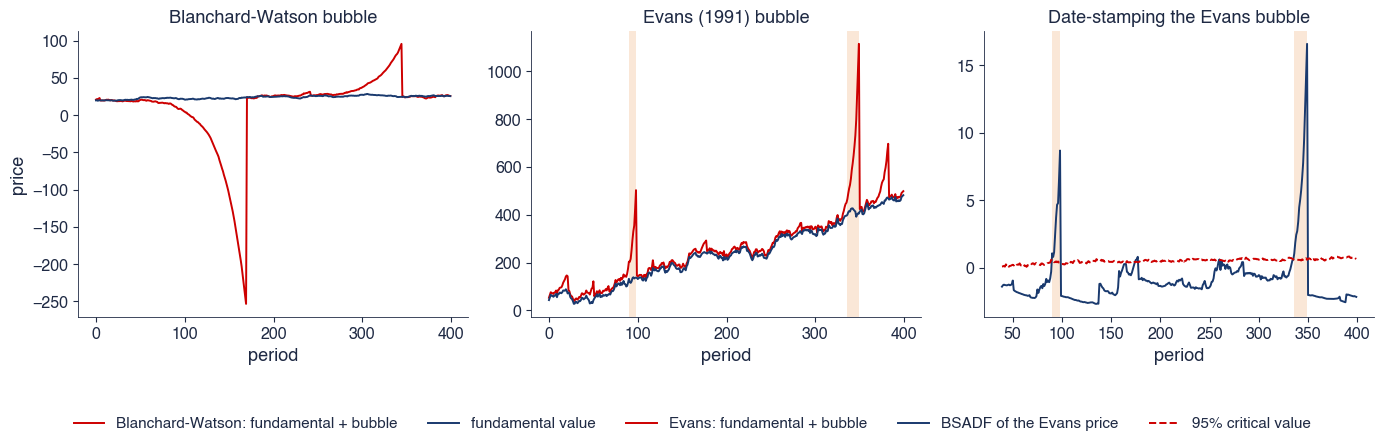

{'T': 399, 'w0': 39, 'r0': 0.1001127113779166, 'adf': -2.8082388752838634, 'sadf': 6.798203326331995, 'gsadf': 16.582910027213785, 'cv': {'adf': {'90': -0.3325460718349178, '95': 0.07897621790619054, '99': 0.6191338675573971}, 'sadf': {'90': 1.0758666526377636, '95': 1.3658364423543472, '99': 1.8570868285435627}, 'gsadf': {'90': 1.9656069629117099, '95': 2.2059702528855176, '99': 2.651600514407403}}, 'n_ep': 2, 'episodes': [(90, 98, 9), (336, 349, 14)], 'L': 6, 'collapses': 18, 'bw_dur': 49.99999999999996, 'R': 500}


In [7]:
def fig_rational(save_it=True, R=2000):
    """Blanchard-Watson bubble; Evans bubble on a present-value fundamental with BSADF against its 95% critical value."""
    T = 400
    rng = np.random.default_rng(SEED)
    fund = 20 + np.cumsum(0.3 * rng.standard_normal(T))
    b = blanchard_watson(T)
    pf, B = evans_price(T)
    p = pf + B
    o = psy(p)
    cv = psy_cv(o['n'], o['w0'], R=R, seed=SEED)
    L = min_len(o['n'])
    ep = episodes(o['bsadf'], cv['bsadf95'], np.arange(1, o['n'] + 1), L)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    axes[0].plot(fund + b, color=st.IDAred, label='Blanchard-Watson: fundamental + bubble')
    axes[0].plot(fund, color=st.MainBlue, label='fundamental value')
    axes[0].set_title('Blanchard-Watson bubble')
    axes[1].plot(p, color=st.IDAred, label='Evans: fundamental + bubble')
    axes[1].plot(pf, color=st.MainBlue, label='_fundamental')
    axes[1].set_title('Evans (1991) bubble')
    axes[2].plot(np.arange(1, o['n'] + 1), o['bsadf'], color=st.MainBlue, label='BSADF of the Evans price')
    axes[2].plot(np.arange(1, o['n'] + 1), cv['bsadf95'], color=st.IDAred, ls='--', label='95% critical value')
    for a_, b_, _ in ep:
        for ax in axes[1:]:
            ax.axvspan(a_, b_, color=st.Orange, alpha=0.18, lw=0)
    axes[2].set_title('Date-stamping the Evans bubble')
    for ax in axes:
        ax.set_xlabel('period')
    axes[0].set_ylabel('price')
    st.fig_legend_bottom(fig, ncol=5, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_rational', save_it)
    bursts = int(np.sum((B[1:] < 0.6 * 20) & (B[:-1] > 1.0 * 20)))
    return dict(T=o['n'], w0=o['w0'], r0=o['r0'], adf=o['adf'], sadf=o['sadf'], gsadf=o['gsadf'],
                cv={k: cv[k] for k in ('adf', 'sadf', 'gsadf')}, n_ep=len(ep), episodes=[(int(a), int(b_), int(n)) for a, b_, n in ep],
                L=L, collapses=bursts, bw_dur=1 / (1 - 0.98), R=R)


print(fig_rational(save_it=False, R=500))

## 2. Cauchy limits of explosive autoregressions

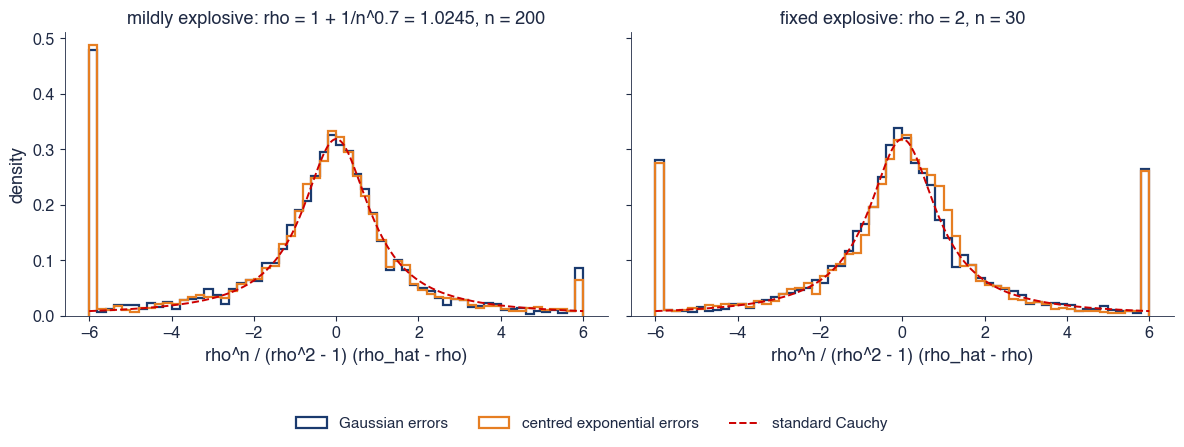

{'mild_normal': {'rho': 1.0245063709469746, 'n': 200, 'ks': 0.06976251444156012, 'ks_p': 1.326000157625111e-21, 'cover': 0.9698, 'q90': 6.6007481504231125}, 'mild_exp': {'rho': 1.0245063709469746, 'n': 200, 'ks': 0.06916456448687425, 'ks_p': 3.0496693824920548e-21, 'cover': 0.972, 'q90': 6.572297487136817}, 'fixed_normal': {'rho': 2.0, 'n': 30, 'ks': 0.008402495784510466, 'ks_p': 0.8689065133810154, 'cover': 0.9452, 'q90': 6.279100131988529}, 'fixed_exp': {'rho': 2.0, 'n': 30, 'ks': 0.022682743906468683, 'ks_p': 0.011477058247909408, 'cover': 0.948, 'q90': 6.18337824344635}, 'mild_big_normal': {'rho': 1.0048896638427147, 'n': 2000, 'ks': 0.029453508572134246, 'ks_p': 0.22386759833798597, 'cover': 0.9512, 'q90': 6.091585318483544}, 'mild_big_exp': {'rho': 1.0048896638427147, 'n': 2000, 'ks': 0.024240749184208488, 'ks_p': 0.44769915296830387, 'cover': 0.9512, 'q90': 6.099370556434354}, 'q90_cauchy': 6.313751514675041, 'R': 5000, 'k': 40.80571546736738}


In [8]:
def fig_asymptotics(save_it=True, R=20000, n=200, n_fixed=30, n_big=2000):
    """Normalised OLS error rho^n/(rho^2 - 1) (rho_hat - rho) for a mildly explosive root rho = 1 + 1/n^0.7 (n = 200)
    and a fixed explosive root rho = 2 (n = 30), Gaussian and centred exponential errors, against the standard Cauchy
    law; coverage of the 95% Cauchy interval rho_hat +- (rho_hat^2 - 1)/rho_hat^n tan(0.475 pi); the mildly explosive
    case again with n = 2000."""
    rng = np.random.default_rng(SEED)
    cases = {'mild': (1 + 1 / n ** 0.7, n), 'fixed': (2.0, n_fixed), 'mild_big': (1 + 1 / n_big ** 0.7, n_big)}
    q975 = np.tan(np.pi * 0.475)
    out, Z = {}, {}
    for k, (rho, nn) in cases.items():
        for dist in ('normal', 'exp'):
            y = ar1_explosive(nn, rho, R if nn <= 200 else R // 4, rng, dist)
            rh = ols_rho(y)
            z = rho ** nn / (rho ** 2 - 1) * (rh - rho)
            half = (rh ** 2 - 1) / rh ** nn * q975
            Z[(k, dist)] = z
            ks = stats.kstest(z, 'cauchy')
            out[f'{k}_{dist}'] = dict(rho=rho, n=nn, ks=float(ks.statistic), ks_p=float(ks.pvalue),
                                      cover=float(np.mean(np.abs(rh - rho) <= half)),
                                      q90=float(np.quantile(np.abs(z), 0.9)))
    out['q90_cauchy'] = float(np.tan(np.pi * 0.45))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    x = np.linspace(-6, 6, 400)
    bins = np.linspace(-6, 6, 61)
    for ax, k, title in ((axes[0], 'mild', f'mildly explosive: rho = 1 + 1/n^0.7 = {cases["mild"][0]:.4f}, n = {n}'),
                         (axes[1], 'fixed', f'fixed explosive: rho = 2, n = {n_fixed}')):
        ax.hist(np.clip(Z[(k, 'normal')], -6, 6), bins=bins, density=True, histtype='step', color=st.MainBlue, lw=1.6,
                label='Gaussian errors' if k == 'mild' else '_')
        ax.hist(np.clip(Z[(k, 'exp')], -6, 6), bins=bins, density=True, histtype='step', color=st.Orange, lw=1.6,
                label='centred exponential errors' if k == 'mild' else '_')
        ax.plot(x, stats.cauchy.pdf(x), color=st.IDAred, ls='--', label='standard Cauchy' if k == 'mild' else '_')
        ax.set_title(title)
        ax.set_xlabel('rho^n / (rho^2 - 1) (rho_hat - rho)')
    axes[0].set_ylabel('density')
    st.fig_legend_bottom(fig, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_asymptotics', save_it)
    out.update(R=R, k=float(n ** 0.7))
    return out


print(fig_asymptotics(save_it=False, R=5000))

## 3. Null distributions and critical values

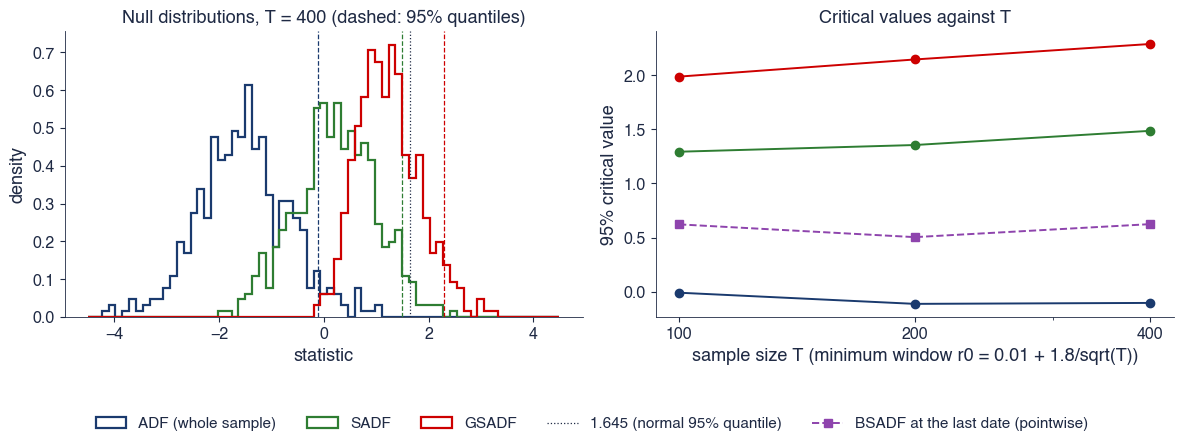

{'100': {'w0': 19, 'r0': 0.19, 'adf': {'90': -0.40947858676959753, '95': -0.010081859164872814, '99': 0.9949732111620716}, 'sadf': {'90': 1.0021052499608865, '95': 1.292938050027058, '99': 1.7702596371830304}, 'gsadf': {'90': 1.666410992418511, '95': 1.9871684850567832, '99': 2.751909295804626}, 'bsadf_end': 0.6215046971305282, 'windows': 3403}, '200': {'w0': 27, 'r0': 0.13727922061357856, 'adf': {'90': -0.3795313330243097, '95': -0.11324104623955317, '99': 0.642884979646901}, 'sadf': {'90': 1.0582647639082714, '95': 1.3548595163526809, '99': 1.8825728357069018}, 'gsadf': {'90': 1.7954215641412177, '95': 2.145561104614291, '99': 2.8655841731216176}, 'bsadf_end': 0.5035261236328209, 'windows': 15225}, '400': {'w0': 40, 'r0': 0.09999999999999999, 'adf': {'90': -0.45357631952502486, '95': -0.1044588415000478, '99': 0.716402823263703}, 'sadf': {'90': 1.232593289199197, '95': 1.4861856945980474, '99': 1.9987147074343927}, 'gsadf': {'90': 1.9933073256910765, '95': 2.2887509783076436, '99': 2

In [9]:
def fig_null(save_it=True, Ts=(100, 200, 400, 800), R=2000):
    """Null distributions of ADF, SADF and GSADF (T = 400) and the 95% critical values against T."""
    res = {}
    draws = None
    for T in Ts:
        w0, r0 = min_window(T)
        cv = psy_cv(T, w0, R=R if T <= 400 else R // 2, seed=SEED + T)
        res[str(T)] = dict(w0=w0, r0=r0, adf=cv['adf'], sadf=cv['sadf'], gsadf=cv['gsadf'],
                           bsadf_end=float(cv['bsadf95'][-1]), windows=int((T - w0 + 1) * (T - w0 + 2) / 2))
        if T == 400:
            draws = cv['draws']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    bins = np.linspace(-4.5, 4.5, 70)
    for k, c, lab in (('adf', st.MainBlue, 'ADF (whole sample)'), ('sadf', st.Forest, 'SADF'), ('gsadf', st.IDAred, 'GSADF')):
        axes[0].hist(draws[k], bins=bins, density=True, histtype='step', lw=1.6, color=c, label=lab)
        axes[0].axvline(res['400'][k]['95'], color=c, ls='--', lw=0.9, label='_')
    axes[0].axvline(stats.norm.ppf(0.95), color=st.DarkText, ls=':', lw=0.9, label='1.645 (normal 95% quantile)')
    axes[0].set_title('Null distributions, T = 400 (dashed: 95% quantiles)')
    axes[0].set_xlabel('statistic')
    axes[0].set_ylabel('density')
    for k, c, lab in (('adf', st.MainBlue, '_'), ('sadf', st.Forest, '_'), ('gsadf', st.IDAred, '_')):
        axes[1].plot(Ts, [res[str(T)][k]['95'] for T in Ts], 'o-', color=c, label=lab)
    axes[1].plot(Ts, [res[str(T)]['bsadf_end'] for T in Ts], 's--', color=st.Purple, label='BSADF at the last date (pointwise)')
    axes[1].set_xscale('log')
    axes[1].set_xticks(Ts)
    axes[1].set_xticklabels([str(T) for T in Ts])
    axes[1].xaxis.set_minor_formatter(plt.NullFormatter())
    axes[1].set_xlabel('sample size T (minimum window r0 = 0.01 + 1.8/sqrt(T))')
    axes[1].set_ylabel('95% critical value')
    axes[1].set_title('Critical values against T')
    st.fig_legend_bottom(fig, ncol=5, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_null', save_it)
    return res


print(fig_null(save_it=False, Ts=(100, 200, 400), R=500))

## 4. Size under changing volatility; pointwise and family-wise dating

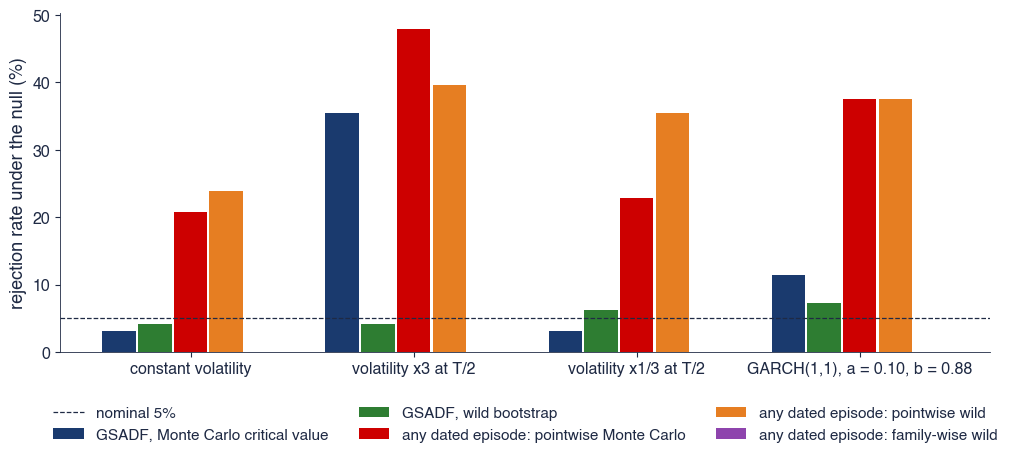

{'T': 200, 'N': 96, 'B': 99, 'w0': 27, 'L': 6, 'Rmc': 1000, 'rates': {'iid': {'rej_mc': 0.03125, 'rej_wild': 0.041666666666666664, 'ep_mc': 0.20833333333333334, 'ep_wild': 0.23958333333333334, 'ep_fw': 0.0}, 'up': {'rej_mc': 0.3541666666666667, 'rej_wild': 0.041666666666666664, 'ep_mc': 0.4791666666666667, 'ep_wild': 0.3958333333333333, 'ep_fw': 0.0}, 'down': {'rej_mc': 0.03125, 'rej_wild': 0.0625, 'ep_mc': 0.22916666666666666, 'ep_wild': 0.3541666666666667, 'ep_fw': 0.0}, 'garch': {'rej_mc': 0.11458333333333333, 'rej_wild': 0.07291666666666667, 'ep_mc': 0.375, 'ep_wild': 0.375, 'ep_fw': 0.0}}}


In [10]:
def vol_path(kind, T):
    """Volatility path of the null model: constant, a rise or a fall at T/2 (GARCH paths are drawn in _size_job)."""
    if kind == 'up':
        return np.r_[np.ones(T // 2), 3 * np.ones(T - T // 2)]
    if kind == 'down':
        return np.r_[np.ones(T // 2), np.ones(T - T // 2) / 3]
    return np.ones(T)


def _size_job(args):
    kind, T, w0, seeds, B, mc = args
    out = []
    for sd in seeds:
        rng = np.random.default_rng(sd)
        if kind == 'garch':
            om, a, b = 0.02, 0.10, 0.88
            h, e = np.empty(T), rng.standard_normal(T)
            h[0] = om / (1 - a - b)
            for t in range(1, T):
                h[t] = om + a * h[t - 1] * e[t - 1] ** 2 + b * h[t - 1]
            y = np.r_[0, np.cumsum(1.0 / T + np.sqrt(h) * e)]
        else:
            y = null_paths(T, 1, rng, vol_path(kind, T))[0]
        o = psy(y, w0=w0)
        wb = wild_cv(y, w0, B=B, seed=sd + 1)
        L = min_len(T)
        idx = np.arange(1, T + 1)
        out.append(dict(rej_mc=o['gsadf'] > mc['gsadf95'], rej_wild=o['gsadf'] > wb['gsadf95'],
                        ep_mc=len(episodes(o['bsadf'], mc['bsadf95'], idx, L)) > 0,
                        ep_wild=len(episodes(o['bsadf'], wb['bsadf95'], idx, L)) > 0,
                        ep_fw=len(episodes(o['bsadf'], wb['gsadf95'], idx, L)) > 0))
    return kind, out


def fig_size(save_it=True, T=200, N=400, B=199, Rmc=4000):
    """Rejection rates under the null for four volatility patterns: GSADF with Monte Carlo and wild-bootstrap critical
    values; share of paths with at least one dated episode (pointwise Monte Carlo, pointwise wild, family-wise wild)."""
    w0, r0 = min_window(T)
    cv = psy_cv(T, w0, R=Rmc, seed=SEED)
    mc = dict(gsadf95=cv['gsadf']['95'], bsadf95=cv['bsadf95'])
    kinds = ['iid', 'up', 'down', 'garch']
    jobs = []
    for i, k in enumerate(kinds):
        seeds = [SEED * 10 + 100000 * i + j for j in range(N)]
        jobs += [(k, T, w0, seeds[j::8], B, mc) for j in range(8)]
    res = {k: [] for k in kinds}
    for k, o in _pool(_size_job, jobs):
        res[k] += o
    rates = {k: {m: float(np.mean([r[m] for r in v])) for m in ('rej_mc', 'rej_wild', 'ep_mc', 'ep_wild', 'ep_fw')}
             for k, v in res.items()}
    fig, ax = plt.subplots(figsize=(12, 4.4))
    labs = {'iid': 'constant volatility', 'up': 'volatility x3 at T/2', 'down': 'volatility x1/3 at T/2',
            'garch': 'GARCH(1,1), a = 0.10, b = 0.88'}
    meas = [('rej_mc', 'GSADF, Monte Carlo critical value', st.MainBlue), ('rej_wild', 'GSADF, wild bootstrap', st.Forest),
            ('ep_mc', 'any dated episode: pointwise Monte Carlo', st.IDAred),
            ('ep_wild', 'any dated episode: pointwise wild', st.Orange),
            ('ep_fw', 'any dated episode: family-wise wild', st.Purple)]
    x = np.arange(len(kinds))
    for j, (m, lab, c) in enumerate(meas):
        ax.bar(x + (j - 2) * 0.16, [100 * rates[k][m] for k in kinds], width=0.15, color=c, label=lab)
    ax.axhline(5, color=st.DarkText, ls='--', lw=0.9, label='nominal 5%')
    ax.set_xticks(x)
    ax.set_xticklabels([labs[k] for k in kinds])
    ax.set_ylabel('rejection rate under the null (%)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('ats_ch16_size', save_it)
    return dict(T=T, N=N, B=B, w0=w0, L=min_len(T), Rmc=Rmc, rates=rates)


print(fig_size(save_it=False, N=96, B=99, Rmc=1000))

## 5. Accuracy of date-stamping

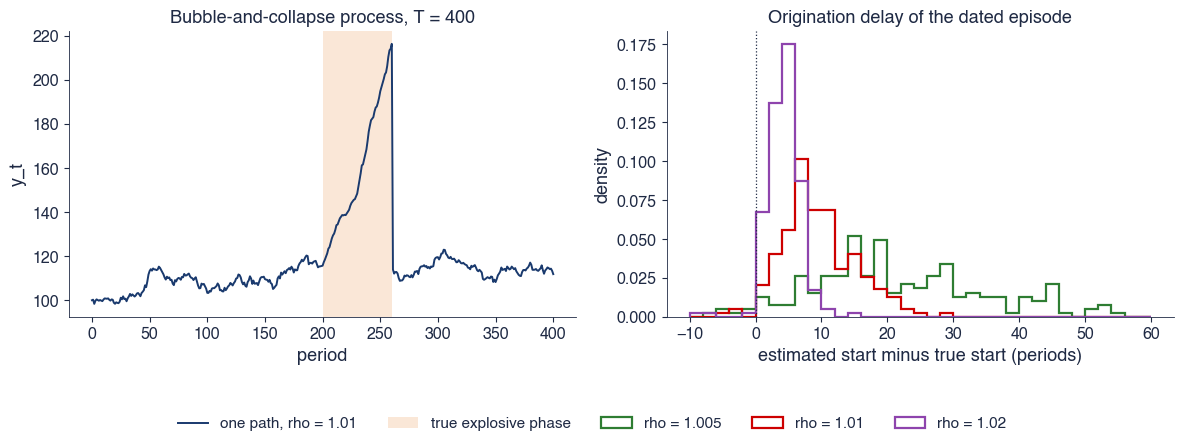

{'1.005': {'det': 0.965, 'med_start': 19.0, 'q25': 13.0, 'q75': 29.0, 'med_conf': 24.0, 'med_end': 0.0, 'false_before': 0.235, 'growth': 1.3488501525493075}, '1.01': {'det': 1.0, 'med_start': 8.0, 'q25': 5.0, 'q75': 12.0, 'med_conf': 13.0, 'med_end': 0.0, 'false_before': 0.335, 'growth': 1.8166966985640913}, '1.02': {'det': 1.0, 'med_start': 4.0, 'q25': 2.0, 'q75': 5.0, 'med_conf': 9.0, 'med_end': 0.0, 'false_before': 0.265, 'growth': 3.2810307883654146}, 'T': 400, 'N': 200, 'te': 200, 'tf': 260, 'dur': 60, 'w0': 40, 'L': 6}


In [11]:
def _dating_job(args):
    rho, T, te, tf, w0, cvb, seeds = args
    L = min_len(T)
    out = []
    for sd in seeds:
        y = bubble_collapse(T, te, tf, rho, y0=100.0, sd=1.0, rng=np.random.default_rng(sd))
        o = psy(y, w0=w0)
        ep = episodes(o['bsadf'], cvb, np.arange(1, T + 1), L)
        hit = [e for e in ep if e[1] >= te + 1 and e[0] <= tf + L]
        false_before = any(e[0] < te + 1 - 0 and e[1] < te + 1 for e in ep)
        if hit:
            e = hit[0]
            out.append(dict(det=True, start=e[0] - (te + 1), end=e[1] - tf, conf=e[0] + L - 1 - (te + 1), fb=false_before))
        else:
            out.append(dict(det=False, start=np.nan, end=np.nan, conf=np.nan, fb=false_before))
    return rho, out


def fig_dating(save_it=True, T=400, N=1000, rhos=(1.005, 1.01, 1.02), R=2000):
    """Bubble-and-collapse paths: random walk from y_0 = 100, explosive on (0.5T, 0.65T], collapse, random walk.
    BSADF dating with the pointwise 95% Monte Carlo critical values and a minimum duration of ceil(ln T)."""
    w0, r0 = min_window(T)
    cvb = psy_cv(T, w0, R=R, seed=SEED)['bsadf95']
    te, tf = int(0.5 * T), int(0.65 * T)
    jobs = []
    for rho in rhos:
        seeds = [SEED + 7919 * j + int(1e5 * rho) for j in range(N)]
        jobs += [(rho, T, te, tf, w0, cvb, seeds[j::8]) for j in range(8)]
    res = {r: [] for r in rhos}
    for r, o in _pool(_dating_job, jobs):
        res[r] += o
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    ex = bubble_collapse(T, te, tf, rhos[1], rng=np.random.default_rng(SEED))
    axes[0].plot(np.arange(T + 1), ex, color=st.MainBlue, label=f'one path, rho = {rhos[1]}')
    axes[0].axvspan(te, tf, color=st.Orange, alpha=0.18, lw=0, label='true explosive phase')
    axes[0].set_xlabel('period')
    axes[0].set_ylabel('y_t')
    axes[0].set_title('Bubble-and-collapse process, T = 400')
    bins = np.arange(-10, 61, 2)
    for rho, c in zip(rhos, (st.Forest, st.IDAred, st.Purple)):
        d = pd.DataFrame(res[rho])
        st_ = d['start'].dropna()
        axes[1].hist(st_, bins=bins, histtype='step', lw=1.6, color=c, density=True, label=f'rho = {rho}')
        out[str(rho)] = dict(det=float(d['det'].mean()), med_start=float(st_.median()) if len(st_) else np.nan,
                             q25=float(st_.quantile(0.25)) if len(st_) else np.nan,
                             q75=float(st_.quantile(0.75)) if len(st_) else np.nan,
                             med_conf=float(d['conf'].dropna().median()) if len(st_) else np.nan,
                             med_end=float(d['end'].dropna().median()) if len(st_) else np.nan,
                             false_before=float(d['fb'].mean()), growth=float(rho ** (tf - te)))
    axes[1].axvline(0, color=st.DarkText, ls=':', lw=0.9, label='_')
    axes[1].set_xlabel('estimated start minus true start (periods)')
    axes[1].set_ylabel('density')
    axes[1].set_title('Origination delay of the dated episode')
    st.fig_legend_bottom(fig, ncol=5, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_dating', save_it)
    out.update(T=T, N=N, te=te, tf=tf, dur=tf - te, w0=w0, L=min_len(T))
    return out


print(fig_dating(save_it=False, N=200, R=500))

## 6. Real-time monitoring

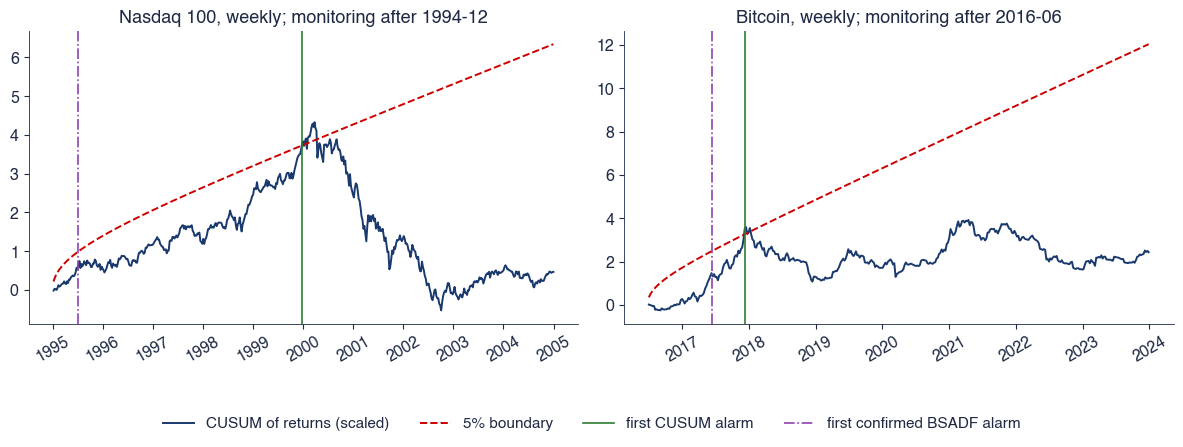

{'ndx': {'train_end': '1994-12-31', 'n': 260, 'cusum_alarm': '1999-12-24', 'bsadf_start': '1995-05-19', 'bsadf_conf': '1995-06-30', 'peak': '2000-03-24'}, 'btc': {'train_end': '2016-06-30', 'n': 92, 'cusum_alarm': '2017-12-08', 'bsadf_start': '2017-04-28', 'bsadf_conf': '2017-06-09', 'peak': '2021-11-12'}, 'size': {'iid': 0.02, 'garch': 0.072}, 'a': 2.500277710809414, 'Nsize': 500}


In [12]:
def fig_monitor(save_it=True, R=1000, Nsize=2000):
    """CUSUM monitoring of weekly returns with the Chu-Stinchcombe-White boundary (training: 1990-1994 for the Nasdaq
    100, 2014-09 to 2016-06 for Bitcoin) against the first real-time BSADF alarm; size of the monitor under i.i.d.
    and GARCH returns."""
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for ax, key, tr_end in ((axes[0], 'ndx', '1994-12-31'), (axes[1], 'btc', '2016-06-30')):
        sym, crypto, a, b, lab = SAMPLES[key]
        y = weekly(prices(sym, crypto)).loc[a:b]
        r = np.diff(y.values)
        idx = y.index[1:]
        n = int((idx <= pd.Timestamp(tr_end)).sum())
        S, bd, hit = cusum_monitor(r, n)
        o = psy(y.values)
        cvb = psy_cv(o['n'], o['w0'], R=R, seed=SEED)['bsadf95']
        L = min_len(o['n'])
        ep = [e for e in episodes(o['bsadf'], cvb, idx, L) if e[0] > pd.Timestamp(tr_end)]
        conf = idx[list(idx).index(ep[0][0]) + L - 1] if ep else None
        ax.plot(idx[n:], S, color=st.MainBlue, label='CUSUM of returns (scaled)')
        ax.plot(idx[n:], bd, color=st.IDAred, ls='--', label='5% boundary')
        if hit is not None:
            ax.axvline(idx[hit], color=st.Forest, lw=1.2, label='first CUSUM alarm')
        if conf is not None:
            ax.axvline(conf, color=st.Purple, lw=1.2, ls='-.', label='first confirmed BSADF alarm')
        ax.set_title(lab.split(',')[0] + ', weekly; monitoring after ' + tr_end[:7])
        ax.tick_params(axis='x', labelrotation=30)
        out[key] = dict(train_end=tr_end, n=n, cusum_alarm=d2s(idx[hit]) if hit is not None else None,
                        bsadf_start=d2s(ep[0][0]) if ep else None, bsadf_conf=d2s(conf) if conf is not None else None,
                        peak=d2s(np.exp(y).idxmax()))
    handles, labels = [], []
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    st.fig_legend_bottom(fig, handles, labels, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_monitor', save_it)
    # size of the monitor: training n = 100, monitoring up to 5n
    rng = np.random.default_rng(SEED)
    n0, H = 100, 500
    hits = {'iid': 0, 'garch': 0}
    for _ in range(Nsize):
        e = rng.standard_normal(H)
        hits['iid'] += cusum_monitor(e, n0)[2] is not None
        om, a, b = 0.02, 0.10, 0.88
        h, z = np.empty(H), rng.standard_normal(H)
        h[0] = om / (1 - a - b)
        for t in range(1, H):
            h[t] = om + a * h[t - 1] * z[t - 1] ** 2 + b * h[t - 1]
        hits['garch'] += cusum_monitor(np.sqrt(h) * z, n0)[2] is not None
    out['size'] = {k: v / Nsize for k, v in hits.items()}
    out['a'] = csw_constant(0.05)
    out['Nsize'] = Nsize
    return out


print(fig_monitor(save_it=False, R=300, Nsize=500))

## 7. Fundamentals against prices: housing

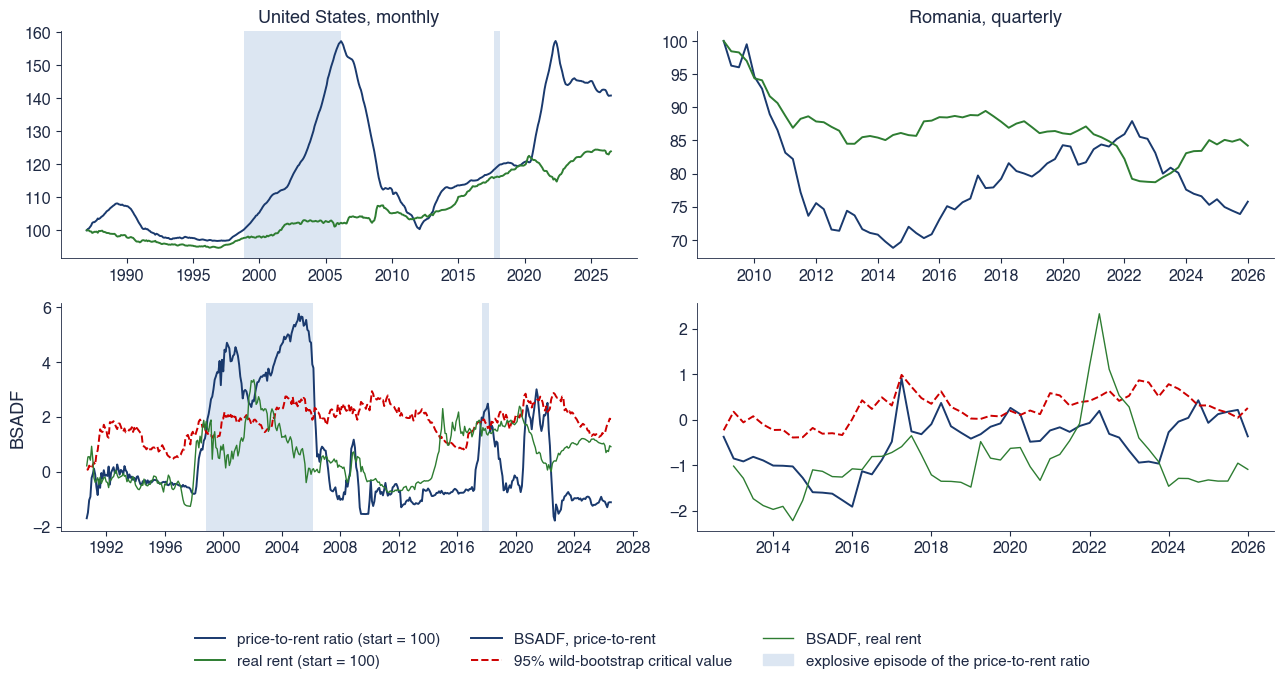

{'us_ratio': {'T': 473, 'w0': 43, 'k': 1, 'gsadf': 5.751815545028768, 'cv': 4.530982241589593, 'L': 7, 'first': '1987-01-01', 'last': '2026-07-01', 'episodes': [('1998-11-01', '2006-03-01', 89), ('2017-09-01', '2018-03-01', 7)], 'peak': '2022-05-01', 'max': 1.5727939190803697}, 'us_rent': {'T': 473, 'w0': 43, 'k': 1, 'gsadf': 3.3485192557123664, 'cv': 3.085557180945992, 'L': 7, 'first': '1987-01-01', 'last': '2026-07-01', 'episodes': [('1998-02-01', '1999-03-01', 14), ('2001-04-01', '2004-09-01', 42), ('2014-09-01', '2021-05-01', 81), ('2023-09-01', '2026-06-01', 33)], 'peak': '2025-05-01', 'max': 1.2442845678741665}, 'us_price': {'T': 473, 'w0': 43, 'k': 3, 'gsadf': 5.309221841415727, 'cv': 3.893888642446752, 'L': 7, 'first': '1987-01-01', 'last': '2026-07-01', 'episodes': [('2001-12-01', '2006-03-01', 52), ('2020-12-01', '2022-05-01', 18)], 'peak': '2022-05-01', 'max': 1.8132467449871936}, 'ro_ratio': {'T': 68, 'w0': 15, 'k': 0, 'gsadf': 0.9052833159999865, 'cv': 1.432706969521657, '

In [13]:
def ro_housing():
    """Romanian house price index (Eurostat prc_hpi_q, 2015 = 100) over the quarterly mean of the HICP actual rentals
    index (prc_hicp_minr, CP041) and over the HICP all-items index."""
    hpi = read_eurostat('prc_hpi_q', 'Q.TOTAL.I15_Q.RO')
    rent = read_eurostat('prc_hicp_minr', 'M.I15.CP041.RO')
    cpi = read_eurostat('prc_hicp_minr', 'M.I15.TOTAL.RO')
    q = lambda s: s.groupby(s.index.to_period('Q')).mean()   # noqa: E731
    rq, cq = q(rent), q(cpi)
    hpi.index = hpi.index.to_period('Q')
    df = pd.concat([hpi.rename('hpi'), rq.rename('rent'), cq.rename('cpi')], axis=1).dropna()
    df.index = df.index.to_timestamp()
    return df.loc[:RO_END]


def us_housing():
    """S&P CoreLogic Case-Shiller US national index (SA), CPI rent of primary residence (SA) and CPI (FRED)."""
    df = read_fred(['CSUSHPISA', 'CUSR0000SEHA', 'CPIAUCSL']).dropna()
    df.columns = ['hpi', 'rent', 'cpi']
    return df


def _dating(y, B=499, tau=None, seed=SEED, kmax=0):
    """PSY with k lagged differences (k by BIC up to kmax) and wild-bootstrap critical values under the AR(k) null."""
    k = bic_lag(y, kmax) if kmax else 0
    o = psy(y, k=k)
    wb = wild_cv(y, o['w0'], B=B, seed=seed, tau=tau, k=k)
    return o, wb


def fig_housing(save_it=True, B=999):
    """BSADF of the log price-to-rent ratio and of the log real rent, US (monthly) and Romania (quarterly), with
    pointwise wild-bootstrap critical values."""
    us, ro = us_housing(), ro_housing()
    series = {'us_ratio': np.log(us['hpi'] / us['rent']), 'us_rent': np.log(us['rent'] / us['cpi']),
              'us_price': np.log(us['hpi'] / us['cpi']),
              'ro_ratio': np.log(ro['hpi'] / ro['rent']), 'ro_rent': np.log(ro['rent'] / ro['cpi']),
              'ro_price': np.log(ro['hpi'] / ro['cpi'])}
    out, dat = {}, {}
    for k, s in series.items():
        o, wb = _dating(s.values, B=B, kmax=6 if k.startswith('us') else 4)
        L = min_len(o['n'])
        ep = episodes(o['bsadf'], wb['bsadf95'], s.index[1:], L)
        dat[k] = (s, o, wb, ep)
        out[k] = dict(T=o['n'], w0=o['w0'], k=o['k'], gsadf=o['gsadf'], cv=wb['gsadf95'], L=L, first=d2s(s.index[0]),
                      last=d2s(s.index[-1]), episodes=[(d2s(a), d2s(b), n) for a, b, n in ep],
                      peak=d2s(s.idxmax()), max=float(np.exp(s.max() - s.iloc[0])))
    fig, axes = plt.subplots(2, 2, figsize=(13, 6.4), gridspec_kw=dict(height_ratios=[1, 1]))
    for j, (cty, title) in enumerate((('us', 'United States, monthly'), ('ro', 'Romania, quarterly'))):
        s, o, wb, ep = dat[f'{cty}_ratio']
        s2 = dat[f'{cty}_rent'][0]
        axes[0, j].plot(s.index, 100 * np.exp(s - s.iloc[0]), color=st.MainBlue, label='price-to-rent ratio (start = 100)')
        axes[0, j].plot(s2.index, 100 * np.exp(s2 - s2.iloc[0]), color=st.Forest, label='real rent (start = 100)')
        axes[0, j].set_title(title)
        axes[1, j].plot(s.index[1:], o['bsadf'], color=st.MainBlue, label='BSADF, price-to-rent')
        axes[1, j].plot(s.index[1:], wb['bsadf95'], color=st.IDAred, ls='--', label='95% wild-bootstrap critical value')
        o2, wb2 = dat[f'{cty}_rent'][1], dat[f'{cty}_rent'][2]
        axes[1, j].plot(s2.index[1:], o2['bsadf'], color=st.Forest, lw=1.0, label='BSADF, real rent')
        for a, b, _ in ep:
            for ax in axes[:, j]:
                ax.axvspan(a, b, color=SHADE, lw=0, zorder=0)
    axes[1, 0].set_ylabel('BSADF')
    h, l = [], []
    for ax in axes.ravel():
        for hh, ll in zip(*ax.get_legend_handles_labels()):
            if ll not in l:
                h.append(hh)
                l.append(ll)
    h.append(plt.Rectangle((0, 0), 1, 1, color=SHADE))
    l.append('explosive episode of the price-to-rent ratio')
    st.fig_legend_bottom(fig, h, l, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.09, 1, 1))
    save('ats_ch16_housing', save_it)
    out['B'] = B
    return out


print(fig_housing(save_it=False, B=199))

## 8. Five episodes

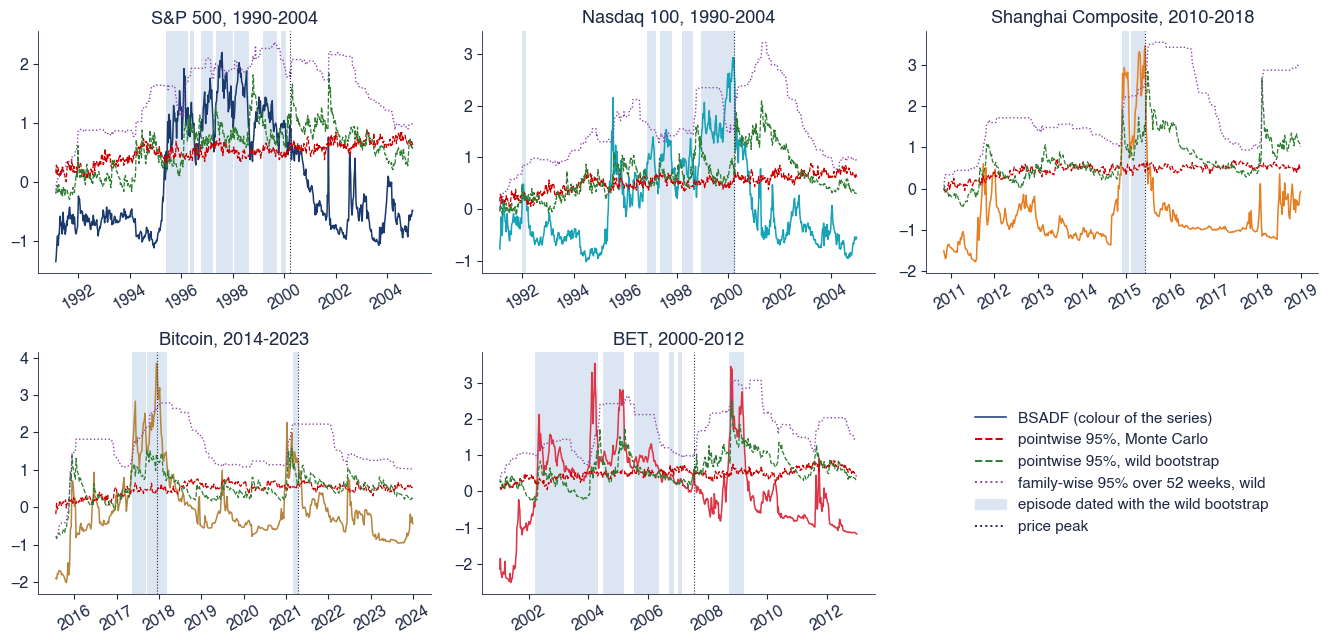

{'sp500': {'T': 782, 'w0': 58, 'L': 7, 'gsadf': 2.19412841796413, 'sadf': 1.803506912738106, 'adf': -1.087435803189117, 'cv_mc': 2.297223850421676, 'cv_wild': 3.003111775953857, 'fwer_end': 0.9841479265651014, 'n_mc': 5, 'n_wild': 7, 'n_fw': 0, 'weeks_mc': 228, 'weeks_wild': 187, 'peaks': [{'peak': '2000-03-24', 'conf': '1999-04-16', 'lead': 49, 'active': False, 'fw_conf': None, 'fw_lead': None, 'fw_active': False, 'fall': -0.25377423958728895}], 'ep_wild': [('1995-06-02', '1996-04-05', 45), ('1996-05-10', '1996-07-05', 9), ('1996-10-04', '1997-03-28', 26), ('1997-05-09', '1998-01-02', 35), ('1998-01-16', '1998-08-21', 32), ('1999-03-05', '1999-09-17', 29), ('1999-11-12', '2000-01-21', 11)], 'ep_fw': []}, 'ndx': {'T': 782, 'w0': 58, 'L': 7, 'gsadf': 2.9249623593576977, 'sadf': 2.7219107900203587, 'adf': -1.2719472977682977, 'cv_mc': 2.297223850421676, 'cv_wild': 3.2378480729823917, 'fwer_end': 0.9467837904029369, 'n_mc': 6, 'n_wild': 5, 'n_fw': 1, 'weeks_mc': 220, 'weeks_wild': 145, 'p

In [14]:
def _episode_job(key, R=1000, B=499):
    sym, crypto, a, b, lab = SAMPLES[key]
    p = prices(sym, crypto)
    y = weekly(p).loc[a:b]
    o = psy(y.values)
    mc = psy_cv(o['n'], o['w0'], R=R, seed=SEED)
    wb = wild_cv(y.values, o['w0'], B=B, seed=SEED, tau=TAU)
    return key, y, o, mc, wb


def run_episodes(R=1000, B=499):
    """PSY statistics, Monte Carlo and wild-bootstrap critical values of the five weekly samples (one process each)."""
    if 'episodes' not in _MEM:
        if PROCS == 1:
            res = [_episode_job(k, R, B) for k in SAMPLES]
        else:
            from multiprocessing import get_context
            with get_context('fork').Pool(len(SAMPLES)) as pool:
                res = pool.starmap(_episode_job, [(k, R, B) for k in SAMPLES])
        _MEM['episodes'] = {k: v for k, *v in res}
    return _MEM['episodes']


def fig_episodes(save_it=True, R=1000, B=499):
    """Weekly log prices: BSADF against the pointwise Monte Carlo and wild-bootstrap 95% critical values; episodes dated
    with the wild bootstrap; for each peak the first alarm, the confirmation date and the fall in the next year."""
    E = run_episodes(R, B)
    out = {}
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.6))
    for ax, key in zip(axes.ravel(), SAMPLES):
        y, o, mc, wb = E[key]
        idx = y.index[1:]
        L = min_len(o['n'])
        ep_mc = episodes(o['bsadf'], mc['bsadf95'], idx, L)
        ep_w = episodes(o['bsadf'], wb['bsadf95'], idx, L)
        ep_fw = episodes(o['bsadf'], wb['fwer95'], idx, L)
        ax.plot(idx, o['bsadf'], color=COLORS[key], lw=1.1, label='_BSADF')
        ax.plot(idx, mc['bsadf95'], color=st.IDAred, ls='--', lw=0.9, label='pointwise 95%, Monte Carlo')
        ax.plot(idx, wb['bsadf95'], color=st.Forest, ls='--', lw=0.9, label='pointwise 95%, wild bootstrap')
        ax.plot(idx, wb['fwer95'], color=st.Purple, ls=':', lw=1.0, label='family-wise 95% over 52 weeks, wild')
        for a, b, _ in ep_w:
            ax.axvspan(a, b, color=SHADE, lw=0, zorder=0)
        px = np.exp(y)
        peaks = []
        for pa, pb in PEAKS[key]:
            pk = px.loc[pa:pb].idxmax()
            ax.axvline(pk, color=st.DarkText, ls=':', lw=0.8)
            after = px.loc[pk:pk + pd.Timedelta(days=365)]
            win = (pk - pd.Timedelta(weeks=104), pk)

            def first_conf(eps):
                c = [idx[list(idx).index(e[0]) + L - 1] for e in eps]
                c = [x for x in c if win[0] <= x <= win[1]]
                return c[0] if c else None

            def active(eps):
                return any(e[0] <= pk + pd.Timedelta(weeks=4) and e[1] >= pk - pd.Timedelta(weeks=4) for e in eps)
            cw, cf = first_conf(ep_w), first_conf(ep_fw)
            peaks.append(dict(peak=d2s(pk), conf=d2s(cw) if cw is not None else None,
                              lead=int((pk - cw).days // 7) if cw is not None else None, active=active(ep_w),
                              fw_conf=d2s(cf) if cf is not None else None,
                              fw_lead=int((pk - cf).days // 7) if cf is not None else None, fw_active=active(ep_fw),
                              fall=float(after.min() / px[pk] - 1)))
        ax.set_title(SAMPLES[key][4])
        ax.tick_params(axis='x', labelrotation=30)
        out[key] = dict(T=o['n'], w0=o['w0'], L=L, gsadf=o['gsadf'], sadf=o['sadf'], adf=o['adf'],
                        cv_mc=mc['gsadf']['95'], cv_wild=wb['gsadf95'], fwer_end=float(wb['fwer95'][-1]),
                        n_mc=len(ep_mc), n_wild=len(ep_w), n_fw=len(ep_fw), weeks_mc=int(sum(e[2] for e in ep_mc)),
                        weeks_wild=int(sum(e[2] for e in ep_w)), peaks=peaks,
                        ep_wild=[(d2s(a), d2s(b), n) for a, b, n in ep_w], ep_fw=[(d2s(a), d2s(b), n) for a, b, n in ep_fw])
    ax = axes.ravel()[-1]
    ax.axis('off')
    h = [plt.Line2D([], [], color=st.MainBlue, lw=1.1), plt.Line2D([], [], color=st.IDAred, ls='--'),
         plt.Line2D([], [], color=st.Forest, ls='--'), plt.Line2D([], [], color=st.Purple, ls=':'),
         plt.Rectangle((0, 0), 1, 1, color=SHADE), plt.Line2D([], [], color=st.DarkText, ls=':')]
    ax.legend(h, ['BSADF (colour of the series)', 'pointwise 95%, Monte Carlo', 'pointwise 95%, wild bootstrap',
                  'family-wise 95% over 52 weeks, wild', 'episode dated with the wild bootstrap', 'price peak'],
              loc='center', frameon=False)
    fig.tight_layout()
    save('ats_ch16_episodes', save_it)
    out['R'], out['B'] = R, B
    return out


print(fig_episodes(save_it=False, R=300, B=199))

## 9. LPPLS: Shanghai 2015

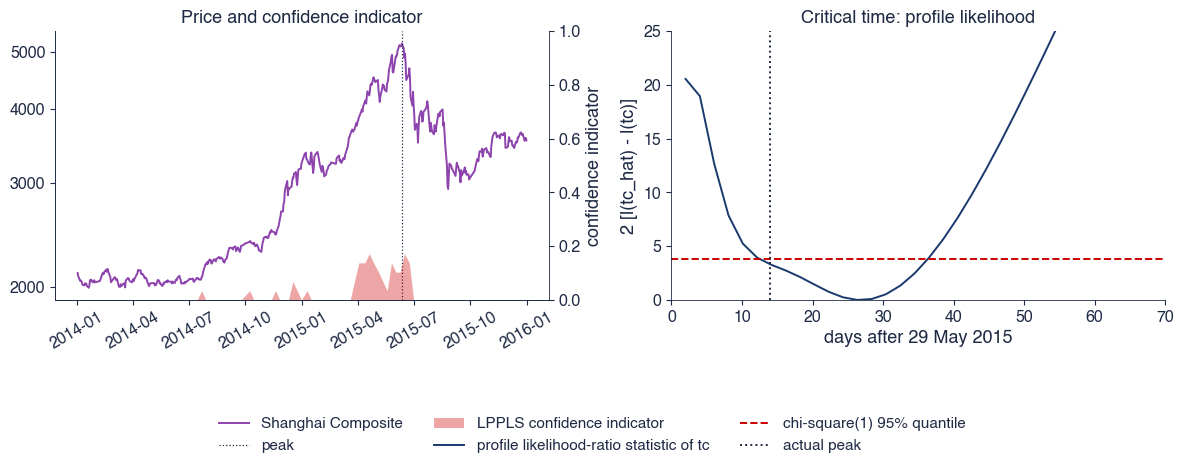

{'low': '2014-03-20', 'peak': '2015-06-12', 't2': '2015-05-29', 'n': 293, 'tc': '2015-06-24', 'm': 0.41415556242573126, 'w': 6.27794360971616, 'B': -1.311567078392582, 'osc': 5.6847439269808895, 'damping': 1.1640736078985638, 'qualified': True, 'cond': {'B': True, 'm': True, 'w': True, 'tc': True, 'osc': True, 'damping': True, 'rel_err': True, 'lomb': True, 'ar1': True}, 'tc_prof': '2015-06-24', 'lo': '2015-06-12', 'hi': '2015-07-02', 'width': 20.294943820230685, 'ci_max': 0.1724, 'ci_max_date': '2015-04-20', 'first_ci': '2014-07-22', 'n_points': 66, 'windows': 29}


In [15]:
def fig_lppls(save_it=True):
    """Shanghai Composite: LPPLS confidence indicator from June 2014 to September 2015; profile likelihood of the
    critical time for the window from the March 2014 low to 29 May 2015."""
    s = prices('SSEC.INDX')
    path = os.path.join(HERE, 'ch16_ci_ssec.csv')
    ci = read_cached('ch16_ci_ssec.csv')
    if ci is None:
        ci = confidence_series(s.loc[:'2015-09-30'], '2014-06-01', step=5, procs=PROCS)
        ci.to_csv(path, float_format='%.4f')
    low = s.loc['2014-03-01':'2014-07-31'].idxmin()
    peak = s.loc['2015-01-01':'2015-12-31'].idxmax()
    t2 = pd.Timestamp('2015-05-29')
    x = s.loc[low:t2]
    t, y = yrs(x.index), np.log(x.values)
    f = lppl_fit(t, y)
    c = lppl_conditions(f)
    tcs = np.linspace(t[-1] + 2 / 365.25, t[-1] + 0.5, 90)
    prof = tc_profile(t, y, tcs)
    lr = 2 * (np.nanmax(prof) - prof)
    inside = tcs[lr <= stats.chi2.ppf(0.95, 1)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    z = s.loc['2014-01-01':'2015-12-31']
    axes[0].plot(z.index, z.values, color=st.Purple, label='Shanghai Composite')
    axes[0].set_yscale('log')
    axes[0].yaxis.set_major_formatter(plt.ScalarFormatter())
    axes[0].yaxis.set_minor_formatter(plt.NullFormatter())
    axes[0].set_yticks([2000, 3000, 4000, 5000])
    ax2 = axes[0].twinx()
    ax2.fill_between(ci.index, 0, ci['ci'], color=st.IDAred, alpha=0.35, lw=0, label='LPPLS confidence indicator')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('confidence indicator')
    ax2.spines['right'].set_visible(True)
    axes[0].axvline(peak, color=st.DarkText, ls=':', lw=0.9, label='peak')
    axes[0].set_title('Price and confidence indicator')
    axes[0].tick_params(axis='x', labelrotation=30)
    days = (tcs - t[-1]) * 365.25
    axes[1].plot(days, lr, color=st.MainBlue, label='profile likelihood-ratio statistic of tc')
    axes[1].axhline(stats.chi2.ppf(0.95, 1), color=st.IDAred, ls='--', label='chi-square(1) 95% quantile')
    axes[1].axvline((yrs([peak])[0] - t[-1]) * 365.25, color=st.DarkText, ls=':', label='actual peak')
    axes[1].set_xlabel('days after 29 May 2015')
    axes[1].set_ylabel('2 [l(tc_hat) - l(tc)]')
    axes[1].set_ylim(0, 25)
    axes[1].set_xlim(0, 70)
    axes[1].set_title('Critical time: profile likelihood')
    h1, l1 = axes[0].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    h3, l3 = axes[1].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h1 + h2 + h3, l1 + l2 + l3, ncol=3, y=0.02)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('ats_ch16_lppls', save_it)
    cmax = ci['ci'].loc[:peak]
    return dict(low=d2s(low), peak=d2s(peak), t2=d2s(t2), n=len(x), tc=d2s(todate(f['tc'])), m=f['m'], w=f['w'],
                B=f['B'], osc=f['osc'], damping=f['damping'], qualified=qualified(c),
                cond={k: v for k, v in c.items()}, tc_prof=d2s(todate(tcs[int(np.nanargmax(prof))])),
                lo=d2s(todate(inside.min())) if len(inside) else None, hi=d2s(todate(inside.max())) if len(inside) else None,
                width=float((inside.max() - inside.min()) * 365.25) if len(inside) else None,
                ci_max=float(cmax.max()), ci_max_date=d2s(cmax.idxmax()),
                first_ci=d2s(ci.index[(ci['ci'] > 0).values][0]) if (ci['ci'] > 0).any() else None,
                n_points=len(ci), windows=len(WINDOWS))


print(fig_lppls(save_it=False))

## 10. Early-warning value over decades

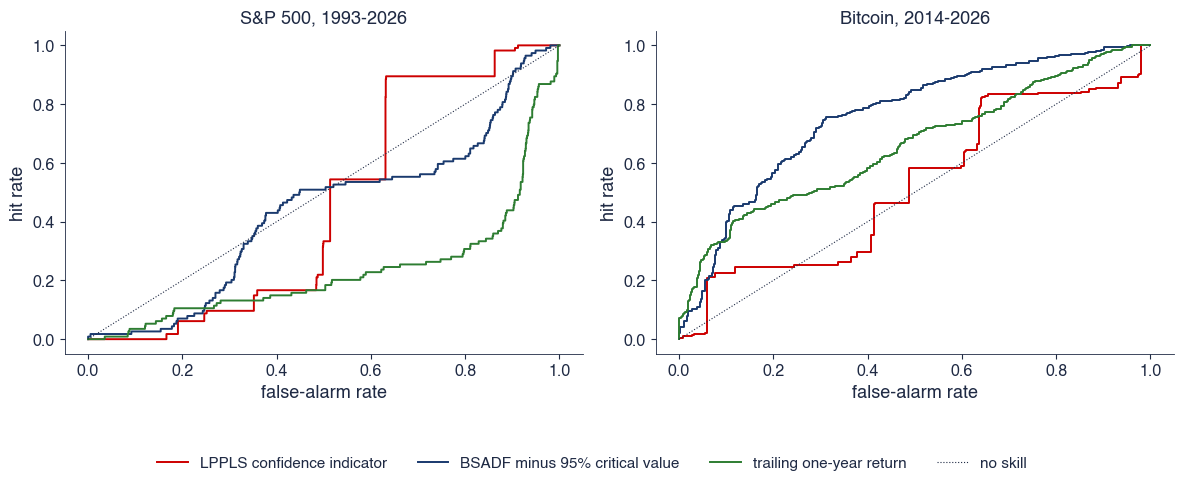

{'sp500': {'ci': {'auc': 0.3867784834358039, 'lo': 0.3190719950982968, 'hi': 0.4806164199512032}, 'bsadf': {'auc': 0.43674976915974145, 'lo': 0.2680335430758067, 'hi': 0.5932382201924995}, 'mom': {'auc': 0.23020404026754948, 'lo': 0.10297954428410422, 'hi': 0.41203823606776335}, 'ci_any': {'hit': 0.16666666666666666, 'false_alarm': 0.37291399229781774, 'precision': 0.03166666666666667, 'base': 0.06818181818181818, 'n_alarm': 600, 'n': 1672}, 'ci_02': {'hit': 0.0, 'false_alarm': 0.10462130937098844, 'precision': 0.0, 'base': 0.06818181818181818, 'n_alarm': 163, 'n': 1672}, 'bsadf_alarm': {'hit': 0.07017543859649122, 'false_alarm': 0.20154043645699615, 'precision': 0.024844720496894408, 'base': 0.06818181818181818, 'n_alarm': 322, 'n': 1672}, 'mom_q90': {'hit': 0.03508771929824561, 'false_alarm': 0.10526315789473684, 'precision': 0.023809523809523808, 'base': 0.06818181818181818, 'n_alarm': 168, 'n': 1672}, 'n': 1672, 'first': '1993-01-04', 'last': '2026-03-19', 'base': 0.068181818181818

In [16]:
def cached_ci(key, recompute=False):
    sym, crypto, a, b = EVAL[key]
    s = prices(sym, crypto).loc[a:]
    path = os.path.join(HERE, f'ch16_ci_{key}.csv')
    ci = None if recompute else read_cached(f'ch16_ci_{key}.csv')
    if ci is not None:
        return s, ci
    ci = confidence_series(s, b, step=5, procs=PROCS)
    ci.to_csv(path, float_format='%.4f')
    return s, ci


def eval_frame(key, R=500):
    """Evaluation dates (the end points of the indicator), scores and the event 'fall of 20% within 182 days'."""
    s, ci = cached_ci(key)
    y = weekly(s)
    o = psy(y.values)
    cvb = psy_cv(o['n'], o['w0'], R=R, seed=SEED)['bsadf95']
    bs = pd.Series(o['bsadf'] - cvb, index=y.index[1:])
    mom = np.log(s).diff(252 if not EVAL[key][1] else 365)
    ff = future_fall(s, HORIZON)
    d = pd.DataFrame({'ci': ci['ci'], 'bsadf': bs.reindex(ci.index, method='ffill'),
                      'mom': mom.reindex(ci.index), 'fall': ff.reindex(ci.index)}).dropna()
    d['event'] = d['fall'] <= -CRASH
    return d, o['w0']


def fig_evaluation(save_it=True, B=999, R=500):
    """ROC curves of three early-warning scores (LPPLS confidence indicator, BSADF minus its pointwise 95% critical
    value, trailing one-year log return) for a 20% fall within 182 days; AUC with moving-block bootstrap intervals."""
    out = {}
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    for ax, key, title in ((axes[0], 'sp500', 'S&P 500, 1993-2026'), (axes[1], 'btc', 'Bitcoin, 2014-2026')):
        d, w0 = eval_frame(key, R=R)
        res = {}
        for sc, lab, c in (('ci', 'LPPLS confidence indicator', st.IDAred), ('bsadf', 'BSADF minus 95% critical value', st.MainBlue),
                           ('mom', 'trailing one-year return', st.Forest)):
            fa, hr = roc(d[sc], d['event'])
            a = auc(d[sc], d['event'])
            bb = block_bootstrap_auc(d[sc].values, d['event'].values, block=26, B=B)
            res[sc] = dict(auc=a, lo=float(np.nanquantile(bb, 0.05)), hi=float(np.nanquantile(bb, 0.95)))
            ax.plot(fa, hr, color=c, label=lab if key == 'sp500' else '_')
        ax.plot([0, 1], [0, 1], color=st.DarkText, ls=':', lw=0.8, label='no skill' if key == 'sp500' else '_')
        ax.set_xlabel('false-alarm rate')
        ax.set_ylabel('hit rate')
        ax.set_title(title)
        res['ci_any'] = alarm_table(d['ci'] > 0, d['event'])
        res['ci_02'] = alarm_table(d['ci'] >= 0.2, d['event'])
        res['bsadf_alarm'] = alarm_table(d['bsadf'] > 0, d['event'])
        res['mom_q90'] = alarm_table(d['mom'] >= d['mom'].quantile(0.9), d['event'])
        res.update(n=len(d), first=d2s(d.index[0]), last=d2s(d.index[-1]), base=float(d['event'].mean()),
                   n_event=int(d['event'].sum()), w0=w0, share_ci_pos=float((d['ci'] > 0).mean()))
        out[key] = res
    st.fig_legend_bottom(fig, ncol=4, y=0.02)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save('ats_ch16_evaluation', save_it)
    out['B'] = B
    return out


print(fig_evaluation(save_it=False, B=199, R=200))

## 11. AI mini-case: a GSADF screen of the course data

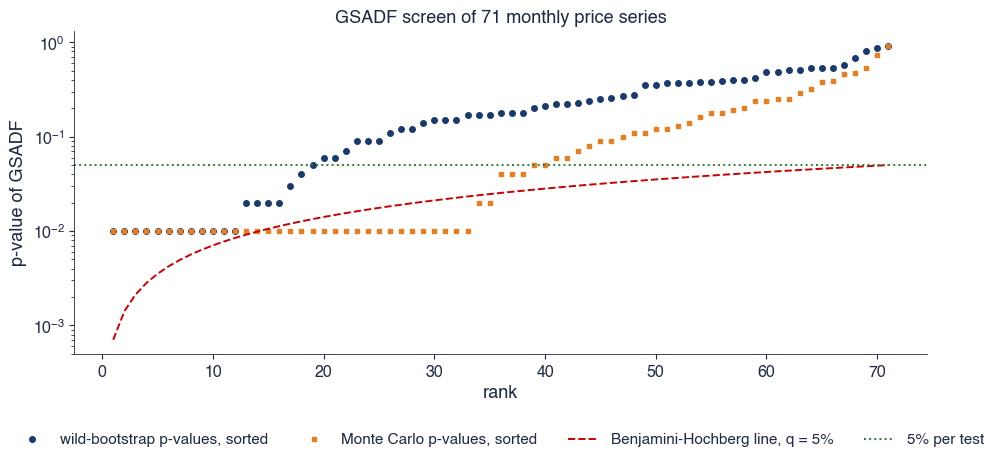

{'K': 71, 'B': 99, 'rej_mc': 40, 'rej_wild': 19, 'holm': 0, 'bh': 0, 'expected': 3.5500000000000003, 'min_p': 0.01, 'table': [{'sym': 'BETFI.INDX', 'T': 175, 'gsadf': 3.160990650483892, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'SNN.RO', 'T': 153, 'gsadf': 3.7338523758843762, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'SNG.RO', 'T': 153, 'gsadf': 3.160711043591079, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'TGN.RO', 'T': 223, 'gsadf': 3.194755467080575, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'BTC-USD.CC', 'T': 193, 'gsadf': 3.321175295646544, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'BETTR.INDX', 'T': 143, 'gsadf': 2.789497420607244, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'BETXT.INDX', 'T': 180, 'gsadf': 3.045061567357309, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'BETNG.INDX', 'T': 175, 'gsadf': 3.2542068146632057, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'GLD.US', 'T': 261, 'gsadf': 3.3912942041382794, 'p_wild': 0.01, 'p_mc': 0.01}, {'sym': 'NVDA.US', 'T': 331, 'gsadf': 3.571812894920922, 'p_wild': 0

In [17]:
def _screen_job(args):
    sym, crypto, B = args
    try:
        s = prices(sym, crypto, 'adjusted_close' if sym.endswith(('.US', '.RO', '.XETRA', '.PA', '.MC', '.LSE', '.AS')) else 'close')
    except Exception:
        return None
    y = np.log(s.resample('ME').last().dropna()).loc[:'2026-08-31']
    y = y.loc['1990-01-01':]
    if len(y) < 121:
        return None
    o = psy(y.values)
    wb = wild_cv(y.values, o['w0'], B=B, seed=SEED)
    rng = np.random.default_rng(SEED)
    bs, _ = bsadf_paths(null_paths(o['n'], B, rng), o['w0'])
    mcd = np.nanmax(bs, axis=1)
    p_w = (1 + np.sum(wb['draws'] >= o['gsadf'])) / (B + 1)
    p_mc = (1 + np.sum(mcd >= o['gsadf'])) / (B + 1)
    return dict(sym=sym, T=o['n'], gsadf=o['gsadf'], p_wild=float(p_w), p_mc=float(p_mc))


def fig_ai_case(save_it=True, B=1999):
    """GSADF on the monthly log price of every series of the course data with at least 10 years (from 1990), p-values
    from the wild bootstrap and from the homoskedastic Monte Carlo null; rejections at 5%, Holm and Benjamini-Hochberg."""
    m = manifest()
    syms = [r for r in m['symbol'] if not any(x in r for x in EXCLUDE)]
    jobs = [(sym, sym.endswith('.CC'), B) for sym in syms]
    res = [r for r in _pool(_screen_job, jobs) if r is not None]
    d = pd.DataFrame(res).sort_values('p_wild').reset_index(drop=True)
    K = len(d)
    holm = int(np.sum(np.cumprod(d['p_wild'].values <= 0.05 / (K - np.arange(K)))))
    pw = np.sort(d['p_wild'].values)
    bhk = np.nonzero(pw <= 0.05 * np.arange(1, K + 1) / K)[0]
    bh = int(bhk[-1] + 1) if len(bhk) else 0
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.plot(np.arange(1, K + 1), pw, 'o', ms=4, color=st.MainBlue, label='wild-bootstrap p-values, sorted')
    ax.plot(np.arange(1, K + 1), np.sort(d['p_mc'].values), 's', ms=3, color=st.Orange, label='Monte Carlo p-values, sorted')
    ax.plot(np.arange(1, K + 1), 0.05 * np.arange(1, K + 1) / K, color=st.IDAred, ls='--', label='Benjamini-Hochberg line, q = 5%')
    ax.axhline(0.05, color=st.Forest, ls=':', label='5% per test')
    ax.set_yscale('log')
    ax.set_xlabel('rank')
    ax.set_ylabel('p-value of GSADF')
    ax.set_title(f'GSADF screen of {K} monthly price series')
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    save('ats_ch16_ai_case', save_it)
    return dict(K=K, B=B, rej_mc=int((d['p_mc'] <= 0.05).sum()), rej_wild=int((d['p_wild'] <= 0.05).sum()), holm=holm,
                bh=bh, expected=0.05 * K, min_p=1 / (B + 1), table=d.to_dict(orient='records'))


print(fig_ai_case(save_it=False, B=99))

## Exercises

1. Add one or two lagged differences (`k`) to the weekly tests of Section 8 and compare the dated episodes.
2. Replace the 20% event of Section 10 by a 30% fall for Bitcoin and recompute base rates, AUC and precision.
3. Rerun the screen of Section 11 with the minimum window chosen for each series in years rather than by `r0 = 0.01 + 1.8/sqrt(T)`, and count the rejections after Holm and Benjamini-Hochberg.